# Structures + BC-augmentation 

Training run `best_sweep_structures_bcaugment_weircrest` (`config_best_sweep_structures_bcaugment_weircrest.yaml`):
trained on the 32-event merged dataset (12 levee/dam structure scenarios on `template_100m_structures.pkl`
+ the same 20 BC-augmentation events used by `best_sweep_bcaugment`), with `edge_weir_crest` turned on
(barrier height above local terrain, see `compute_edge_weir_crest_offset` in `database/convert_sfincs_to_pkl_marg.py`).

In [1]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import copy, pickle
import torch
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config, get_rollout_confusion_matrix, get_CSI
from utils.dataset import (create_model_dataset, get_temporal_test_dataset_parameters,
                           to_temporal_dataset, separate_multiscale_node_features)
from utils.visualization import PlotRollout
from training.train import LightningTrainer, rollout_test_warmstart

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
device = torch.device('cpu')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Models to compare

Each carries its own config (correct scalers - different mesh templates) and evaluates on the standard
held-out 1.0x warmstart event, which is already `test_dataset_name` in both configs - no override needed.

In [2]:
MODELS = [
    {'name': 'weircrest_best_valloss',  'config': 'config_best_sweep_structures_bcaugment_weircrest.yaml',
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_structures_bcaugment_weircrest.h5')},
    {'name': 'weircrest_bestCSI',       'config': 'config_best_sweep_structures_bcaugment_weircrest.yaml',
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_structures_bcaugment_weircrest_bestCSI.h5')},
    {'name': 'bcaugment_best_valloss',  'config': 'config_best_sweep_bcaugment.yaml',  # pre-structures baseline
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment.h5')},
]

for m in MODELS:
    exists = os.path.exists(m['checkpoint'])
    size = f"{os.path.getsize(m['checkpoint'])/1e6:.1f} MB" if exists else 'MISSING'
    print(f"{m['name']:<24} config={m['config']:<48} exists={exists!s:<6} {size:>10}")

weircrest_best_valloss   config=config_best_sweep_structures_bcaugment_weircrest.yaml exists=True       2.5 MB
weircrest_bestCSI        config=config_best_sweep_structures_bcaugment_weircrest.yaml exists=True       2.5 MB
bcaugment_best_valloss   config=config_best_sweep_bcaugment.yaml                 exists=True       2.5 MB


## Load each model's own config + dataset (cached by config path)

Only `test_dataset_name` matters here since it's already each config's default - `train_dataset_name`
stays untouched so scalers fit on each model's real training distribution, not this one held-out event.

In [3]:
dataset_cache = {}  # config_path -> (cfg, test_dataset, scalers, ttdp, num_node_features, num_edge_features)

def get_dataset_for_config(config_path):
    if config_path in dataset_cache:
        return dataset_cache[config_path]

    cfg = read_config(config_path)
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg, reinit=True)
    fix_dict_in_config(wandb)
    config = wandb.config

    _, _, test_dataset, scalers = create_model_dataset(
        scalers=config.scalers, device=device,
        **config.dataset_parameters,
        **config.selected_node_features,
        **config.selected_edge_features,
    )
    ttdp = get_temporal_test_dataset_parameters(config, config.temporal_dataset_parameters)
    temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **ttdp)
    num_node_features = temporal_test_dataset[0].x.size(-1)
    num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

    dataset_cache[config_path] = (dict(cfg), test_dataset, scalers, ttdp, num_node_features, num_edge_features)
    print(f'{config_path}: test_size={len(test_dataset)}  WD shape={test_dataset[0].WD.shape}  '
          f'num_node_features={num_node_features}  num_edge_features={num_edge_features}')
    return dataset_cache[config_path]

for config_path in sorted({m['config'] for m in MODELS}):
    get_dataset_for_config(config_path)

The validation dataset you are using is the training one. Careful!
config_best_sweep_bcaugment.yaml: test_size=1  WD shape=torch.Size([30079, 119])  num_node_features=8  num_edge_features=1
The validation dataset you are using is the training one. Careful!
config_best_sweep_structures_bcaugment_weircrest.yaml: test_size=1  WD shape=torch.Size([30079, 119])  num_node_features=8  num_edge_features=2


## Load each checkpoint and run inference
Architecture (hid_features, K) is auto-detected from each checkpoint's state_dict, not trusted from config.

In [4]:
def load_model_from_checkpoint(checkpoint_path, base_config, num_node_features, num_edge_features, previous_t, num_scales):
    model_parameters = dict(base_config['models'])
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = num_scales

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict']
    hid = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K'] = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features, num_edge_features=num_edge_features,
        previous_t=previous_t, device=device, **model_parameters,
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': base_config['lr_info'],
        'trainer_options': base_config['trainer_options'],
        'temporal_test_dataset_parameters': get_temporal_test_dataset_parameters(base_config, base_config['temporal_dataset_parameters']),
    }
    plmodule = LightningTrainer.load_from_checkpoint(checkpoint_path, map_location=device, **plmodule_kwargs)
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


results = {}
for m in MODELS:
    name, ckpt_path, config_path = m['name'], m['checkpoint'], m['config']
    if not os.path.exists(ckpt_path):
        print(f'[skip] {name}: checkpoint not found at {ckpt_path}')
        continue
    print(f'Loading {name} ...')
    cfg, test_dataset, scalers, ttdp, num_node_features, num_edge_features = get_dataset_for_config(config_path)

    model, hid, K_list = load_model_from_checkpoint(
        ckpt_path, cfg, num_node_features, num_edge_features,
        previous_t=ttdp['previous_t'], num_scales=test_dataset[0].mesh.num_meshes,
    )

    plot_rollout = PlotRollout(model, test_dataset[0], scalers=scalers, warmup_steps=0, **ttdp)

    rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
    loss_mean = rollout_loss.mean(0)
    rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()

    csi_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]
    csi_curve = [plot_rollout._get_CSI(water_threshold=t).nanmean().item() for t in csi_thresholds]

    csi_time_005 = plot_rollout._get_CSI(water_threshold=0.05).detach().cpu().numpy()
    csi_time_03  = plot_rollout._get_CSI(water_threshold=0.30).detach().cpu().numpy()
    if csi_time_005.ndim > 1:
        csi_time_005 = np.nanmean(csi_time_005, axis=0)
        csi_time_03  = np.nanmean(csi_time_03, axis=0)

    results[name] = {
        'config_path': config_path, 'hid_features': hid, 'K': K_list,
        'rmse_wd': rmse_wd,
        'csi_005': csi_curve[csi_thresholds.index(0.05)],
        'csi_03':  csi_curve[csi_thresholds.index(0.30)],
        'csi_thresholds': csi_thresholds, 'csi_curve': csi_curve,
        'csi_time_005': csi_time_005, 'csi_time_03': csi_time_03,
        'plot_rollout': plot_rollout, 'test_dataset': test_dataset,
    }
    print(f'  hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={results[name]["csi_005"]:.4f}  CSI@0.30={results[name]["csi_03"]:.4f}')

Loading weircrest_best_valloss ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.0944  CSI@0.05=0.8716  CSI@0.30=0.9024
Loading weircrest_bestCSI ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1093  CSI@0.05=0.8959  CSI@0.30=0.8972
Loading bcaugment_best_valloss ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1011  CSI@0.05=0.8523  CSI@0.30=0.8986


## Summary table

In [5]:
header = f"{'Model':<24} {'hid':>5} {'K':>22} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}"
print(header)
print('-' * len(header))
for name, r in results.items():
    print(f"{name:<24} {r['hid_features']:>5} {str(r['K']):>22} {r['rmse_wd']:>9.4f} {r['csi_005']:>9.4f} {r['csi_03']:>9.4f}")

Model                      hid                      K   RMSE_WD  CSI@0.05  CSI@0.30
-----------------------------------------------------------------------------------
weircrest_best_valloss      32  [1, 1, 1, 5, 4, 3, 2]    0.0944    0.8716    0.9024
weircrest_bestCSI           32  [1, 1, 1, 5, 4, 3, 2]    0.1093    0.8959    0.8972
bcaugment_best_valloss      32  [1, 1, 1, 5, 4, 3, 2]    0.1011    0.8523    0.8986


## Verdict vs the seed ruler

The ruler is 5 single-sim seeds evaluated on their own training event (memorization regime). Every
model here is evaluated on the held-out 1.0x event, not part of any of their training sets - landing
inside or above the band is a meaningful generalization result.

In [6]:
seed_table = pd.read_csv('results/seed_table.csv')
ruler = seed_table[seed_table.ckpt == 'best_CSI']
RULER_LO, RULER_HI = ruler.CSI_005.min(), ruler.CSI_005.max()
print(f'best_CSI ruler (n={len(ruler)} seeds): CSI@0.05 mean={ruler.CSI_005.mean():.4f} '
      f'+- {ruler.CSI_005.std(ddof=1):.4f}   band [{RULER_LO:.4f}, {RULER_HI:.4f}]')
print()

header = f"{'Model':<24} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}  vs ruler band"
print(header)
print('-' * len(header))
for name, r in results.items():
    c = r['csi_005']
    verdict = 'ABOVE' if c > RULER_HI else ('BELOW' if c < RULER_LO else 'inside')
    print(f"{name:<24} {r['rmse_wd']:>9.4f} {c:>9.4f} {r['csi_03']:>9.4f}  {verdict}")

best_CSI ruler (n=5 seeds): CSI@0.05 mean=0.7609 +- 0.0419   band [0.7116, 0.8111]

Model                      RMSE_WD  CSI@0.05  CSI@0.30  vs ruler band
---------------------------------------------------------------------
weircrest_best_valloss      0.0944    0.8716    0.9024  ABOVE
weircrest_bestCSI           0.1093    0.8959    0.8972  ABOVE
bcaugment_best_valloss      0.1011    0.8523    0.8986  ABOVE


## Diagnostic - checkpoint epoch and per-scale volume sanity check

These checkpoints are mid-training snapshots (training resumes under a 24h SLURM time limit) - worth
confirming exactly which epoch each came from before reading anything into the numbers above.

In [7]:
print('--- checkpoint epochs ---')
epochs = {}
for m in MODELS:
    name = m['name']
    if name not in results:
        continue
    ck = torch.load(m['checkpoint'], map_location='cpu', weights_only=False)
    epochs[name] = ck.get('epoch', -1)
    print(f"{name:<24} epoch={epochs[name]}")

print('\n--- per-scale volume: prediction vs truth at the flood peak (1.0x event) ---')
for name, r in results.items():
    node_ptr = r['test_dataset'][0].node_ptr
    num_scales = len(node_ptr) - 1
    pred_scales = separate_multiscale_node_features(r['plot_rollout'].predicted_rollout, node_ptr)
    real_scales = separate_multiscale_node_features(r['plot_rollout'].real_rollout, node_ptr)
    t_pk0 = int(real_scales[0][:, 0, :].clamp(min=0).sum(0).argmax())
    print(f'{name} (epoch {epochs.get(name, "?")}):')
    for s in range(num_scales):
        p_vol = pred_scales[s][:, 0, t_pk0].clamp(min=0).sum().item()
        g_vol = real_scales[s][:, 0, t_pk0].clamp(min=0).sum().item()
        ratio = p_vol / g_vol if g_vol else float('nan')
        print(f'  scale {s}: pred={p_vol:8.0f}  truth={g_vol:8.0f}  ratio={ratio:.3f}')

--- checkpoint epochs ---
weircrest_best_valloss   epoch=711
weircrest_bestCSI        epoch=652
bcaugment_best_valloss   epoch=243

--- per-scale volume: prediction vs truth at the flood peak (1.0x event) ---
weircrest_best_valloss (epoch 711):
  scale 0: pred=    7396  truth=    7767  ratio=0.952
  scale 1: pred=    1064  truth=    1132  ratio=0.939
  scale 2: pred=     341  truth=     342  ratio=0.995
  scale 3: pred=     101  truth=     102  ratio=0.990
weircrest_bestCSI (epoch 652):
  scale 0: pred=    6006  truth=    7767  ratio=0.773
  scale 1: pred=     855  truth=    1132  ratio=0.755
  scale 2: pred=     268  truth=     342  ratio=0.782
  scale 3: pred=      79  truth=     102  ratio=0.774
bcaugment_best_valloss (epoch 243):
  scale 0: pred=    8233  truth=    7767  ratio=1.060
  scale 1: pred=    1142  truth=    1132  ratio=1.008
  scale 2: pred=     357  truth=     342  ratio=1.043
  scale 3: pred=     102  truth=     102  ratio=1.008


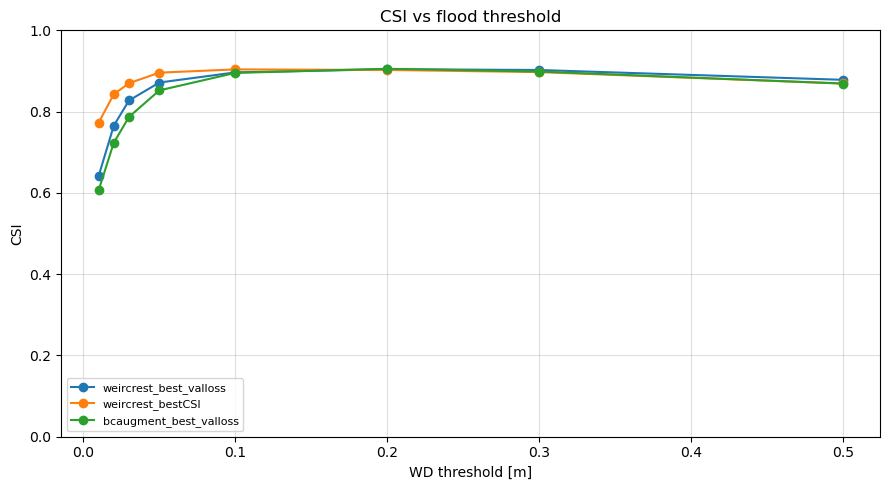

In [8]:
# CSI vs threshold - all models
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    ax.plot(r['csi_thresholds'], r['csi_curve'], 'o-', label=name)
ax.set_xlabel('WD threshold [m]')
ax.set_ylabel('CSI')
ax.set_title('CSI vs flood threshold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

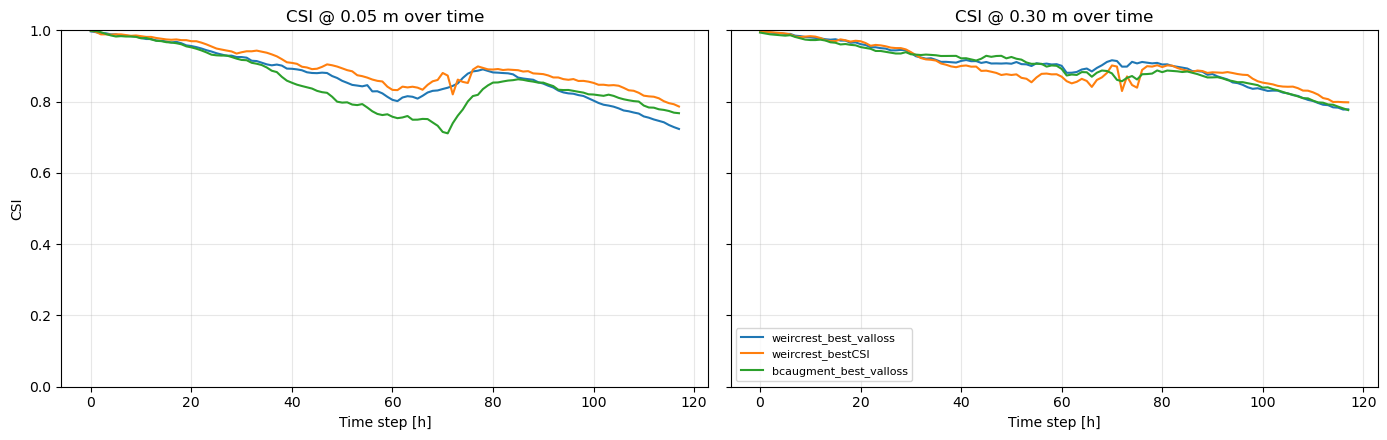

In [9]:
# CSI over time - all models
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for name, r in results.items():
    axes[0].plot(r['csi_time_005'], label=name)
    axes[1].plot(r['csi_time_03'], label=name)
axes[0].set_title('CSI @ 0.05 m over time')
axes[1].set_title('CSI @ 0.30 m over time')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('CSI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

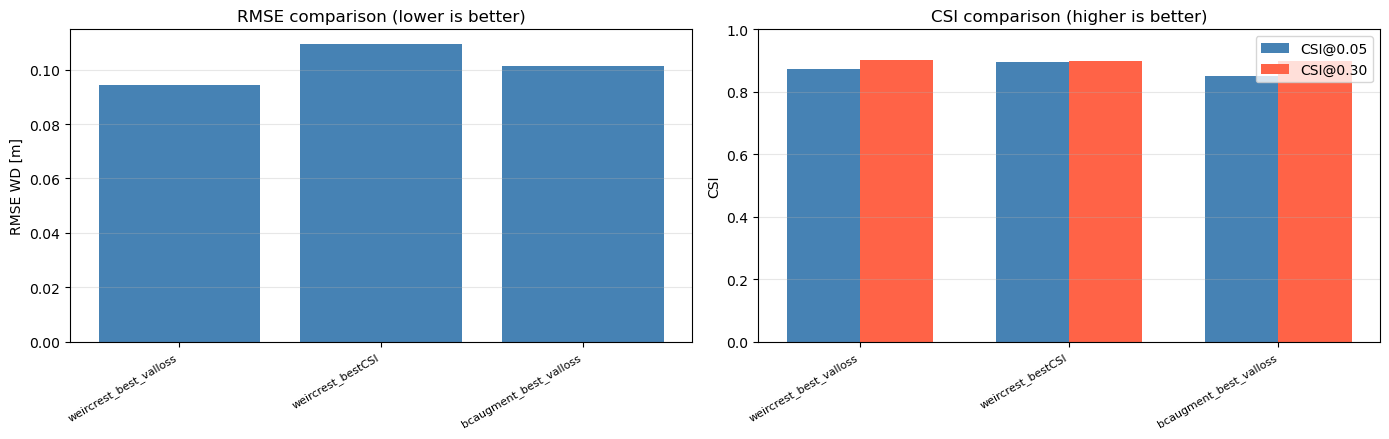

In [10]:
# RMSE / CSI bar comparison
names = list(results.keys())
rmse_vals = [results[n]['rmse_wd'] for n in names]
csi005_vals = [results[n]['csi_005'] for n in names]
csi03_vals = [results[n]['csi_03'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(names))

axes[0].bar(x, rmse_vals, color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('RMSE WD [m]')
axes[0].set_title('RMSE comparison (lower is better)')
axes[0].grid(True, alpha=0.3, axis='y')

width = 0.35
axes[1].bar(x - width/2, csi005_vals, width, label='CSI@0.05', color='steelblue')
axes[1].bar(x + width/2, csi03_vals, width, label='CSI@0.30', color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('CSI')
axes[1].set_ylim(0, 1)
axes[1].set_title('CSI comparison (higher is better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step-0 diagnostics - FP/FN decomposition @ 0.05 m
Timesteps for the spatial maps are picked automatically from each model's own real wet-area curve
(rising limb = half-rise, peak = max wet area, recession = half-fall) - identical ground truth across
models since they all evaluate the same 1.0x event, just possibly on different meshes.

Diagnostic timesteps per model: {'weircrest_best_valloss': {'rising limb': 71, 'peak': 76, 'recession': 117}, 'weircrest_bestCSI': {'rising limb': 71, 'peak': 76, 'recession': 117}, 'bcaugment_best_valloss': {'rising limb': 71, 'peak': 76, 'recession': 117}}


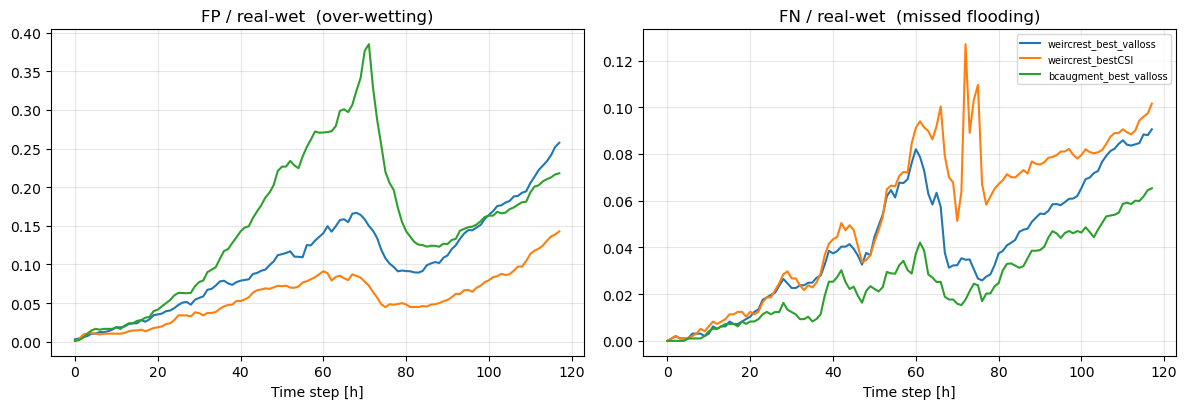

Model                     mean FP/wet  mean FN/wet  dominant error
weircrest_best_valloss          0.105        0.042  FP (over-wetting)
weircrest_bestCSI               0.058        0.054  FP (over-wetting)
bcaugment_best_valloss          0.151        0.026  FP (over-wetting)


In [11]:
THR = 0.05  # m - WD_scaler is None, so rollouts are already in physical units

conf = {}
phases_per_model = {}
for name, r in results.items():
    real_s0 = r['plot_rollout']._real_rollout_s0  # [nodes, vars, time]
    wet_area = (real_s0[:, 0, :] > THR).sum(0).cpu().numpy()
    t_peak = int(wet_area.argmax())
    base = wet_area[0]
    half = base + 0.5 * (wet_area.max() - base)
    rise_c = np.where(wet_area[:t_peak] <= half)[0]
    t_rise = int(rise_c[-1]) if len(rise_c) else max(t_peak // 2, 1)
    rec_c = np.where(wet_area[t_peak:] <= half)[0]
    t_rec = int(t_peak + rec_c[0]) if len(rec_c) else int(wet_area.shape[0] - 1)
    phases_per_model[name] = {'rising limb': t_rise, 'peak': t_peak, 'recession': t_rec}

    TP, TN, FP, FN = get_rollout_confusion_matrix(
        r['plot_rollout']._predicted_rollout_s0, r['plot_rollout']._real_rollout_s0, water_threshold=THR)
    conf[name] = dict(zip(['TP', 'TN', 'FP', 'FN'], [v.cpu().numpy().astype(float) for v in (TP, TN, FP, FN)]))

print('Diagnostic timesteps per model:', phases_per_model)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name, c in conf.items():
    wet = c['TP'] + c['FN']  # real wet cells per timestep
    axes[0].plot(c['FP'] / wet, label=name)
    axes[1].plot(c['FN'] / wet, label=name)
axes[0].set_title('FP / real-wet  (over-wetting)')
axes[1].set_title('FN / real-wet  (missed flooding)')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"{'Model':<24} {'mean FP/wet':>12} {'mean FN/wet':>12}  dominant error")
for name, c in conf.items():
    wet = c['TP'] + c['FN']
    fp, fn = np.nanmean(c['FP'] / wet), np.nanmean(c['FN'] / wet)
    dom = 'FP (over-wetting)' if fp > fn else 'FN (under-prediction)'
    print(f"{name:<24} {fp:>12.3f} {fn:>12.3f}  {dom}")

### Spatial TP / FP / FN maps at rising limb, peak, recession
Red = false alarm (predicted wet, actually dry), orange = miss (predicted dry, actually wet).

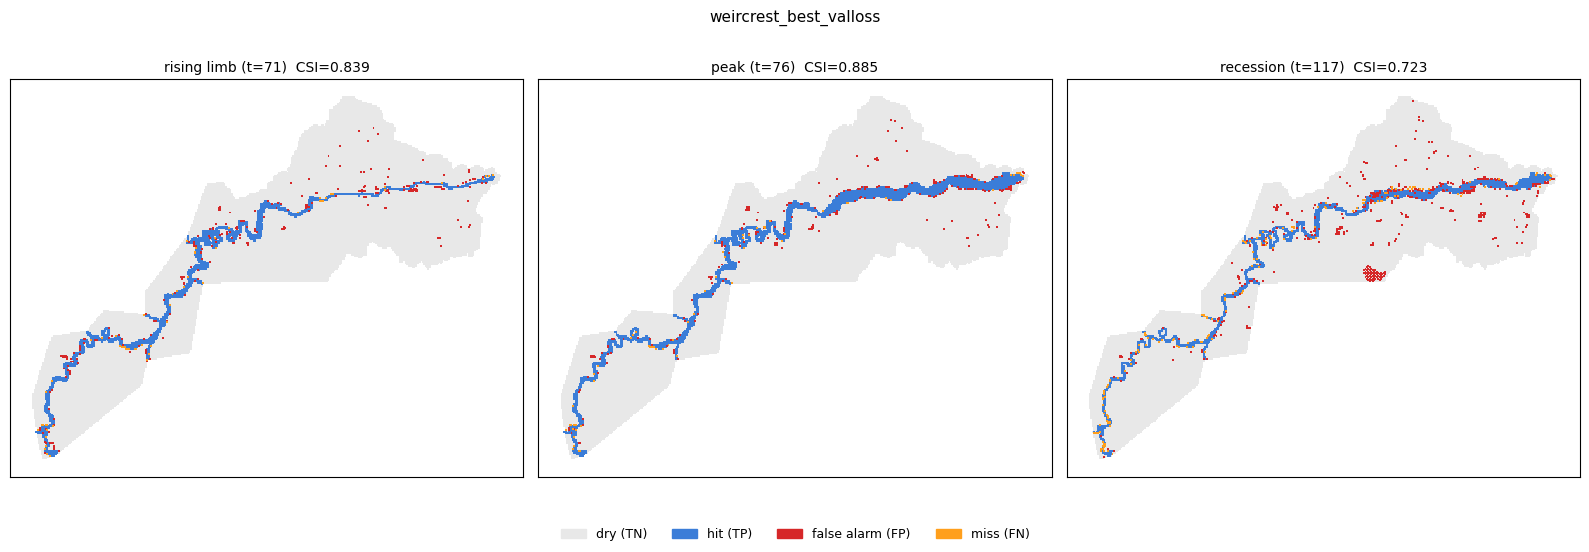

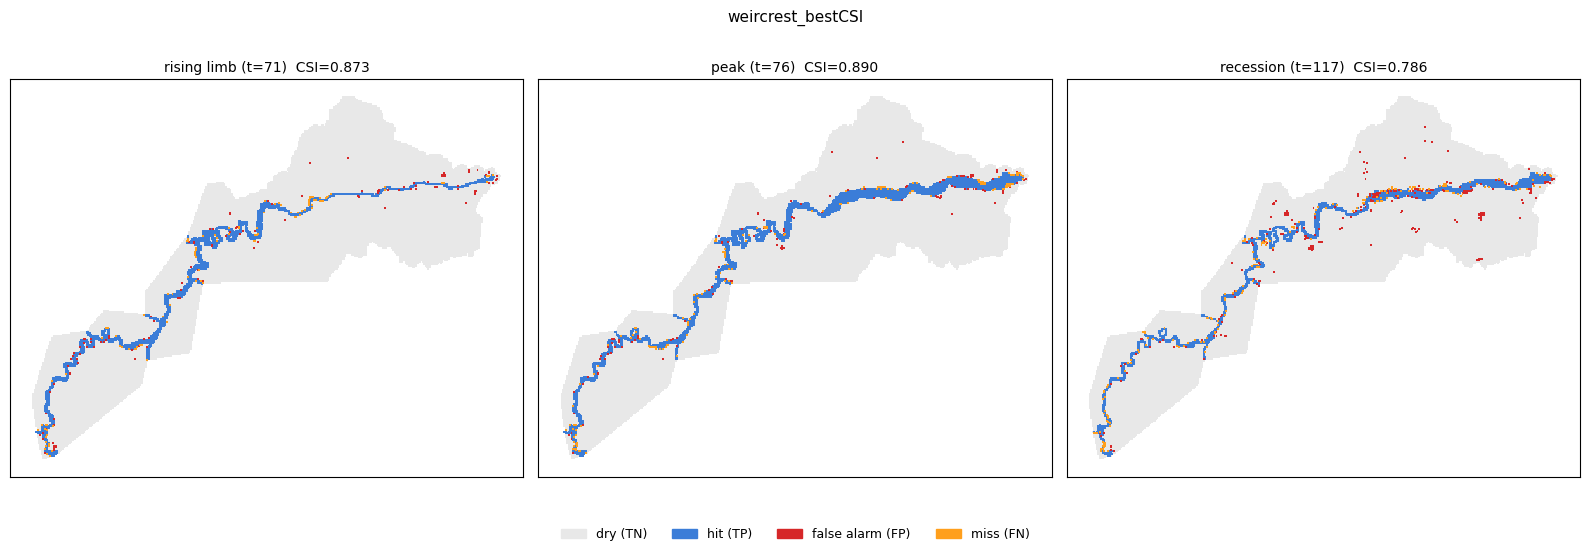

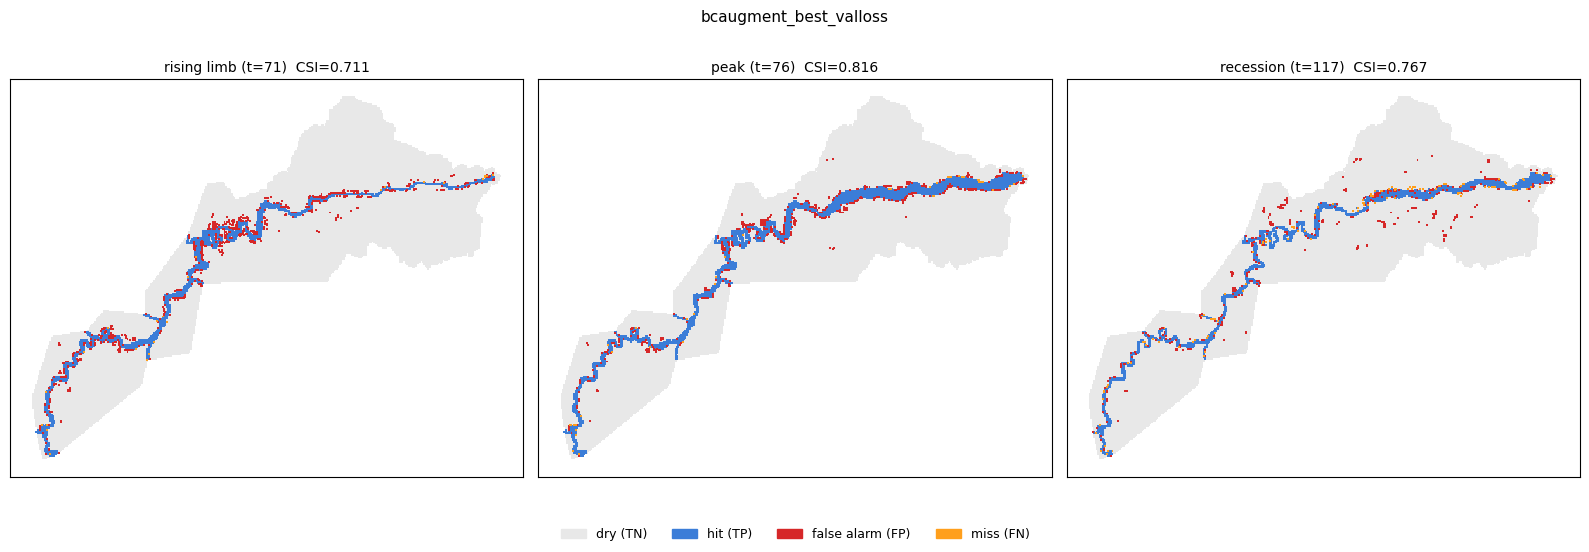

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])  # TN, TP, FP, FN
legend_handles = [Patch(color=c, label=l) for c, l in zip(
    cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

for name, r in results.items():
    phases = phases_per_model[name]
    pred = r['plot_rollout']._predicted_rollout_s0[:, 0, :].cpu().numpy()
    real = r['plot_rollout']._real_rollout_s0[:, 0, :].cpu().numpy()
    n_s0 = pred.shape[0]
    pos_s0 = np.asarray(r['plot_rollout'].pos)[:n_s0]  # PlotRollout stores pos = dataset.mesh.face_xy

    fig, axes = plt.subplots(1, len(phases), figsize=(16, 5.5))
    for ax, (ph, t) in zip(axes, phases.items()):
        p, g = pred[:, t] > THR, real[:, t] > THR
        cat = np.zeros(n_s0, dtype=int)
        cat[p & g] = 1
        cat[p & ~g] = 2
        cat[~p & g] = 3
        order = np.argsort(cat, kind='stable')
        csi_t = (p & g).sum() / max((p | g).sum(), 1)
        ax.scatter(pos_s0[order, 0], pos_s0[order, 1], c=cat[order], cmap=cat_cmap,
                   vmin=0, vmax=3, s=2, marker='s', linewidths=0)
        ax.set_title(f'{ph} (t={t})  CSI={csi_t:.3f}', fontsize=10)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(name, fontsize=11)
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

--- weircrest_best_valloss ---


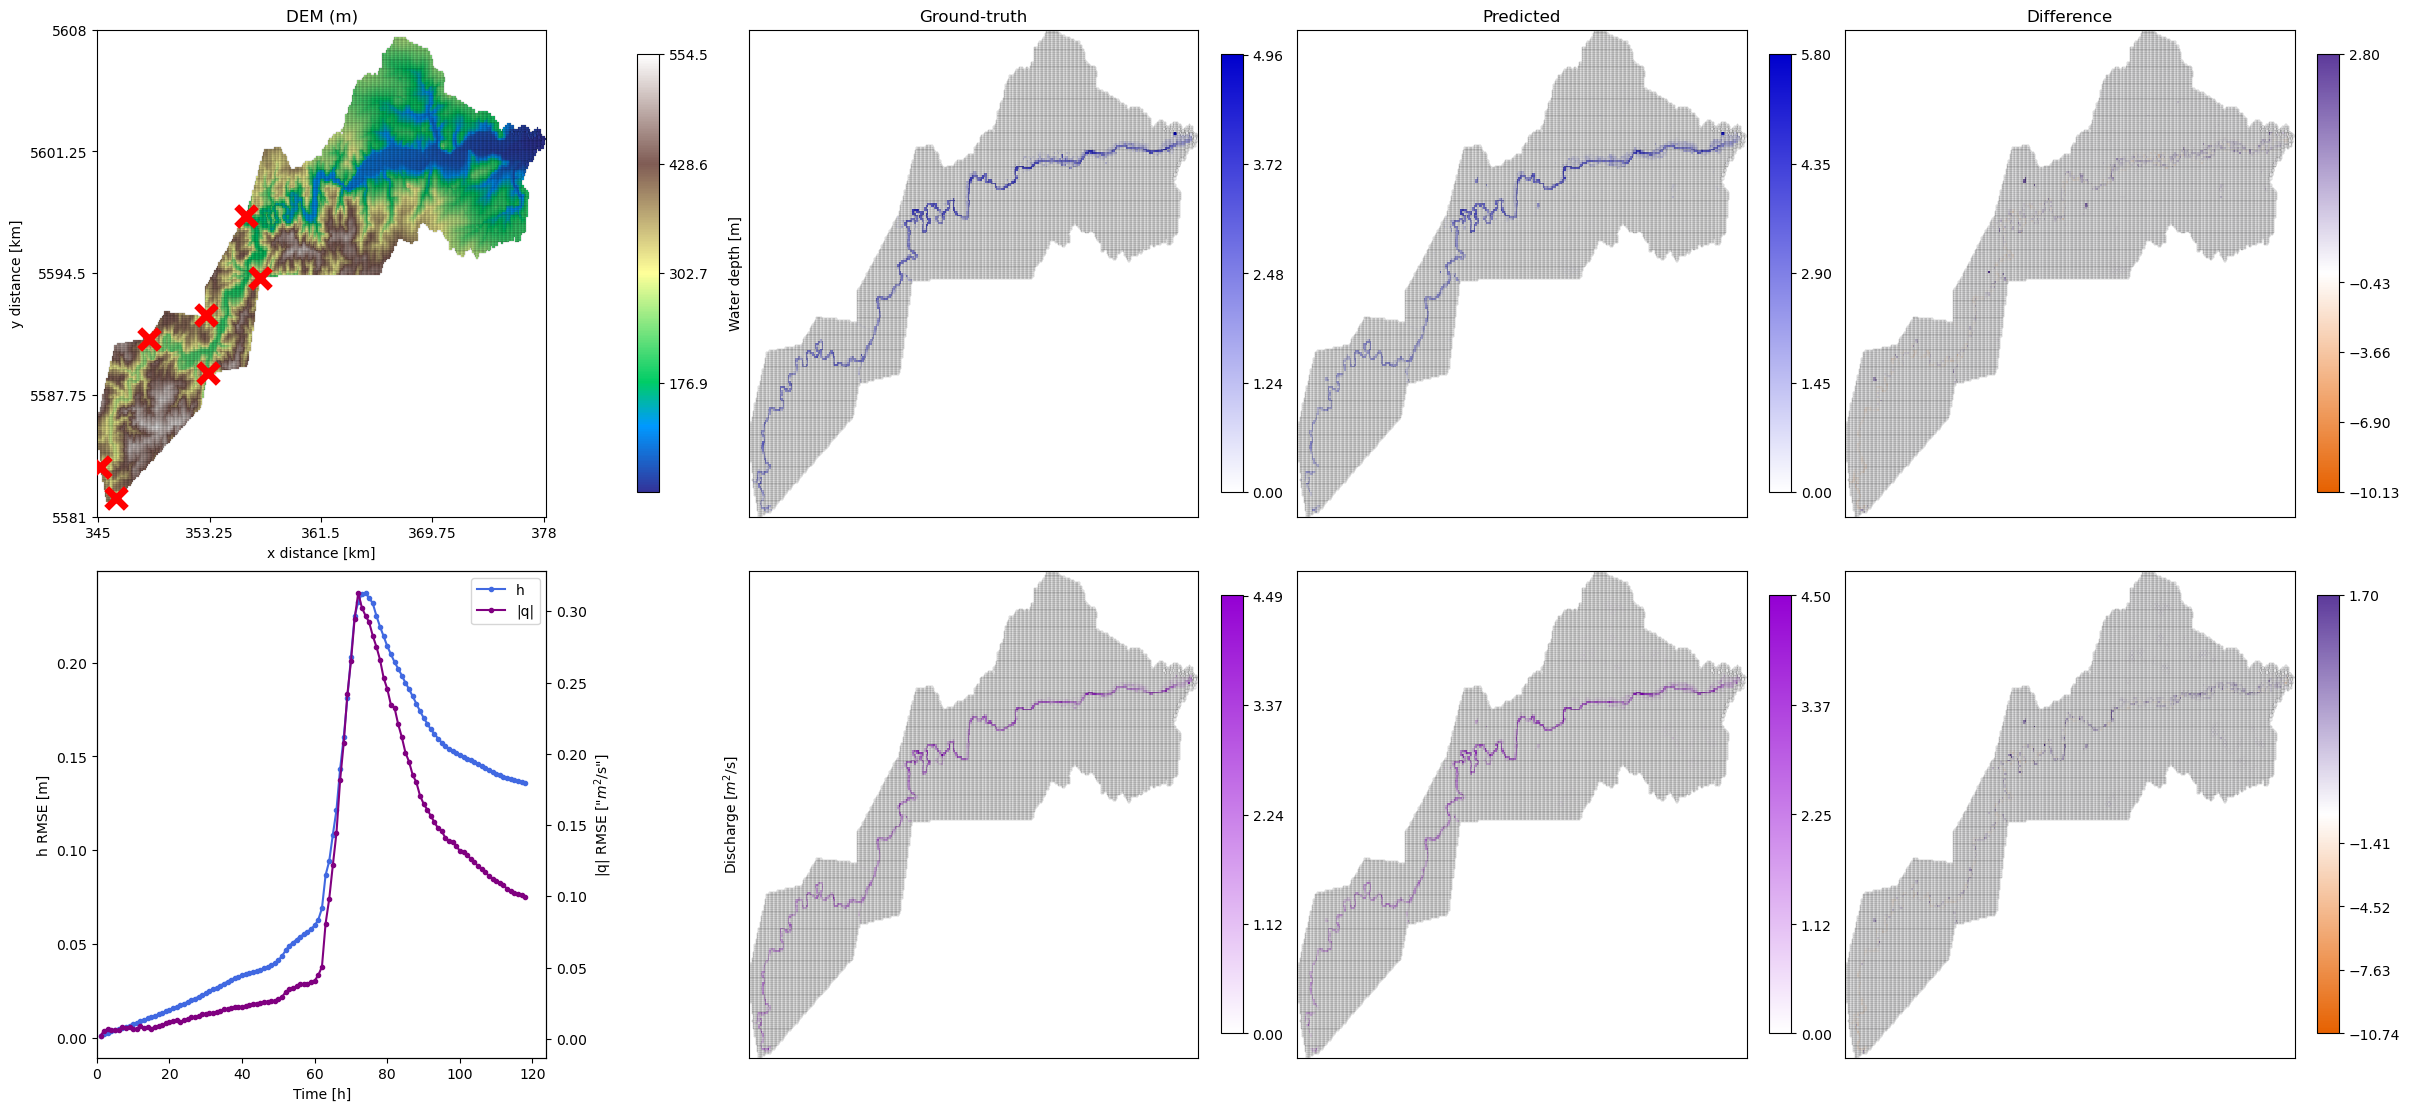

--- weircrest_bestCSI ---


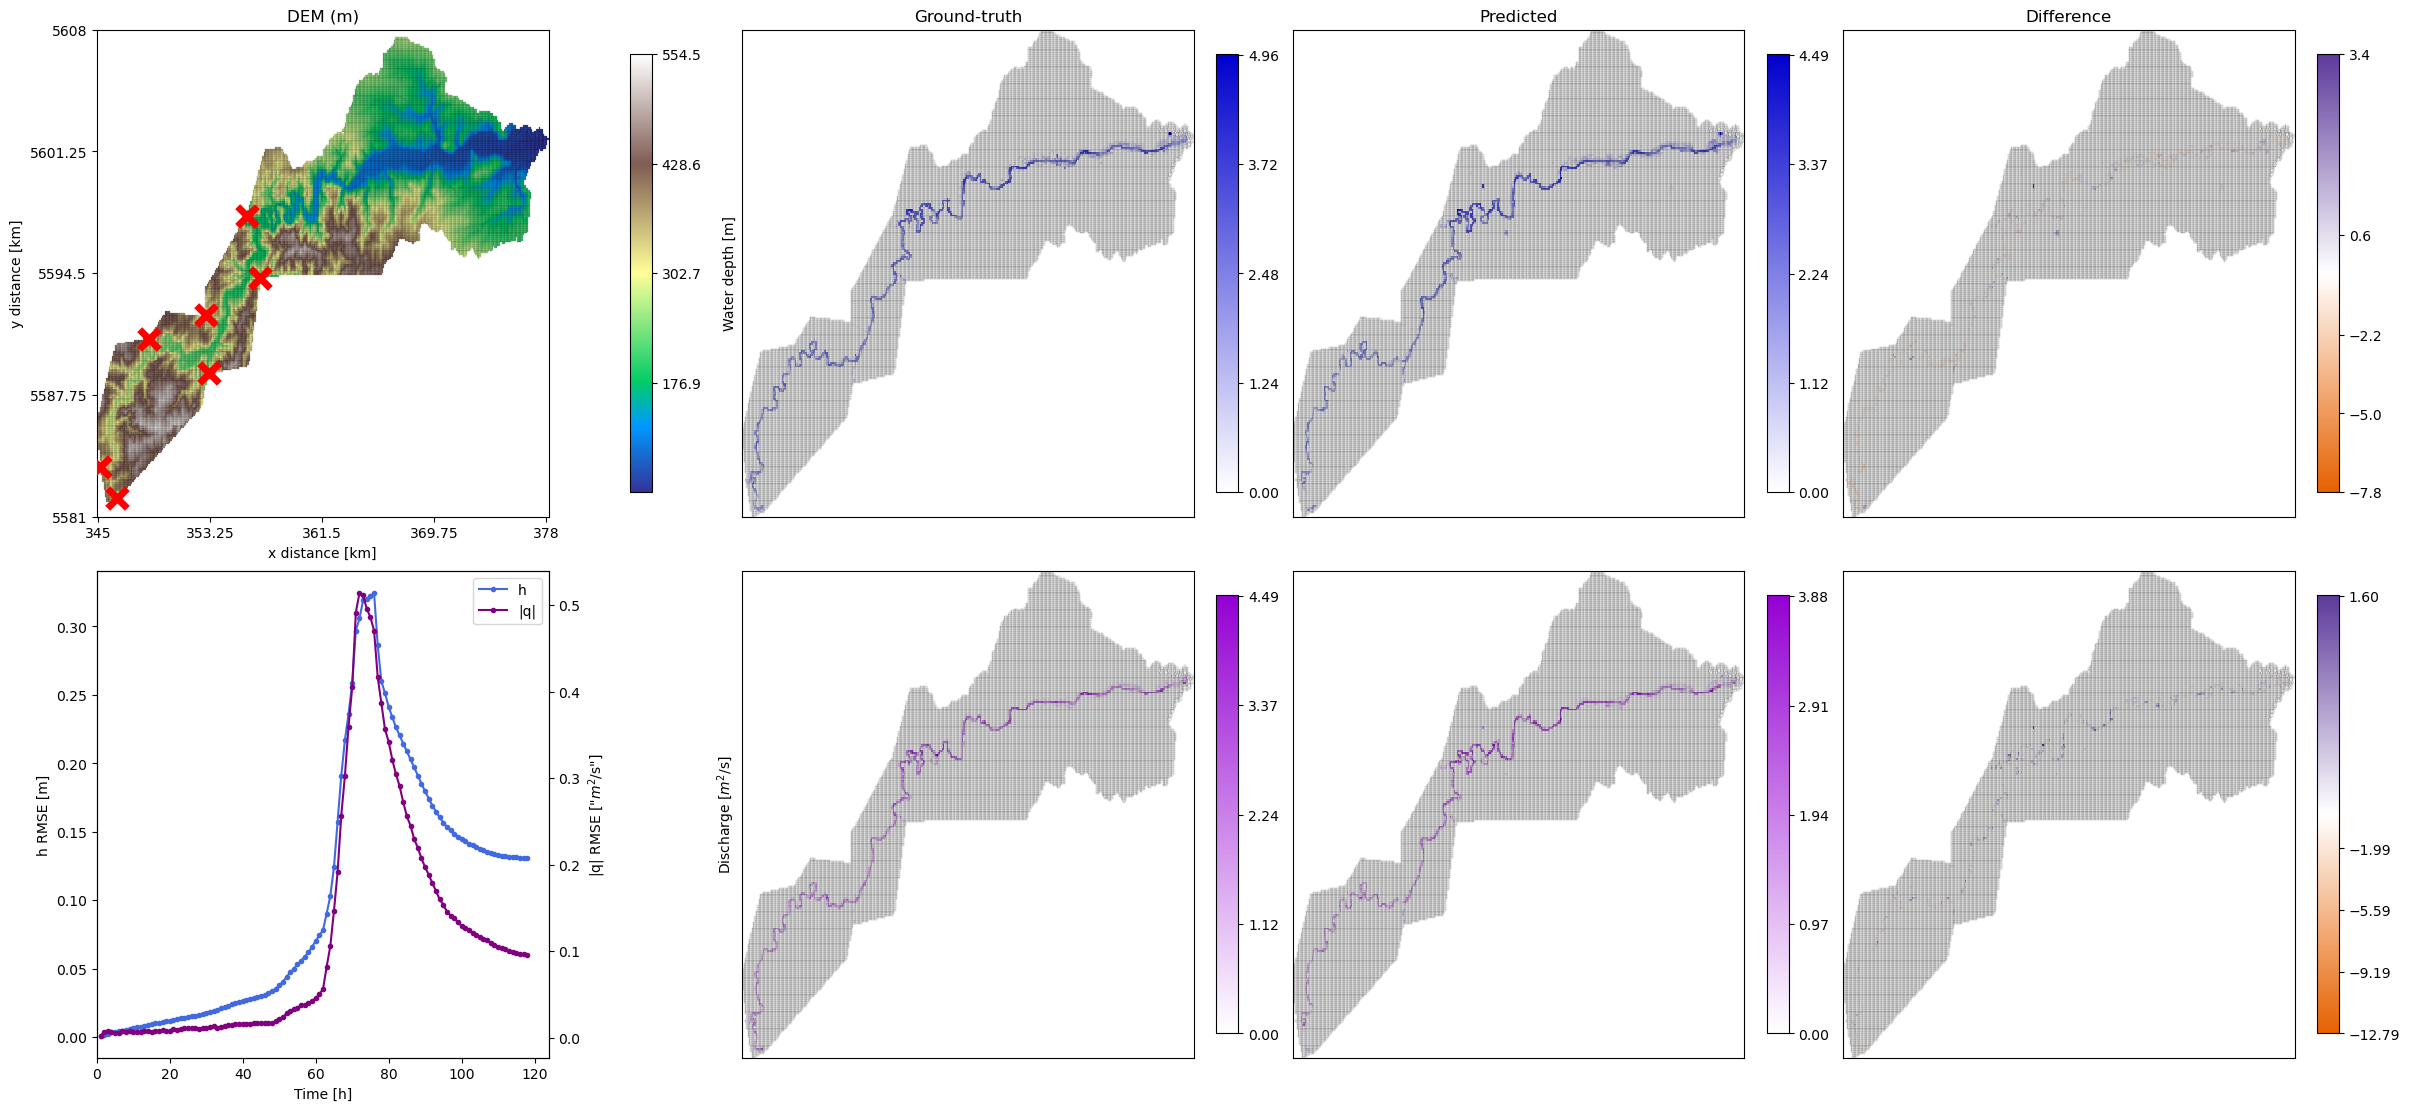

--- bcaugment_best_valloss ---


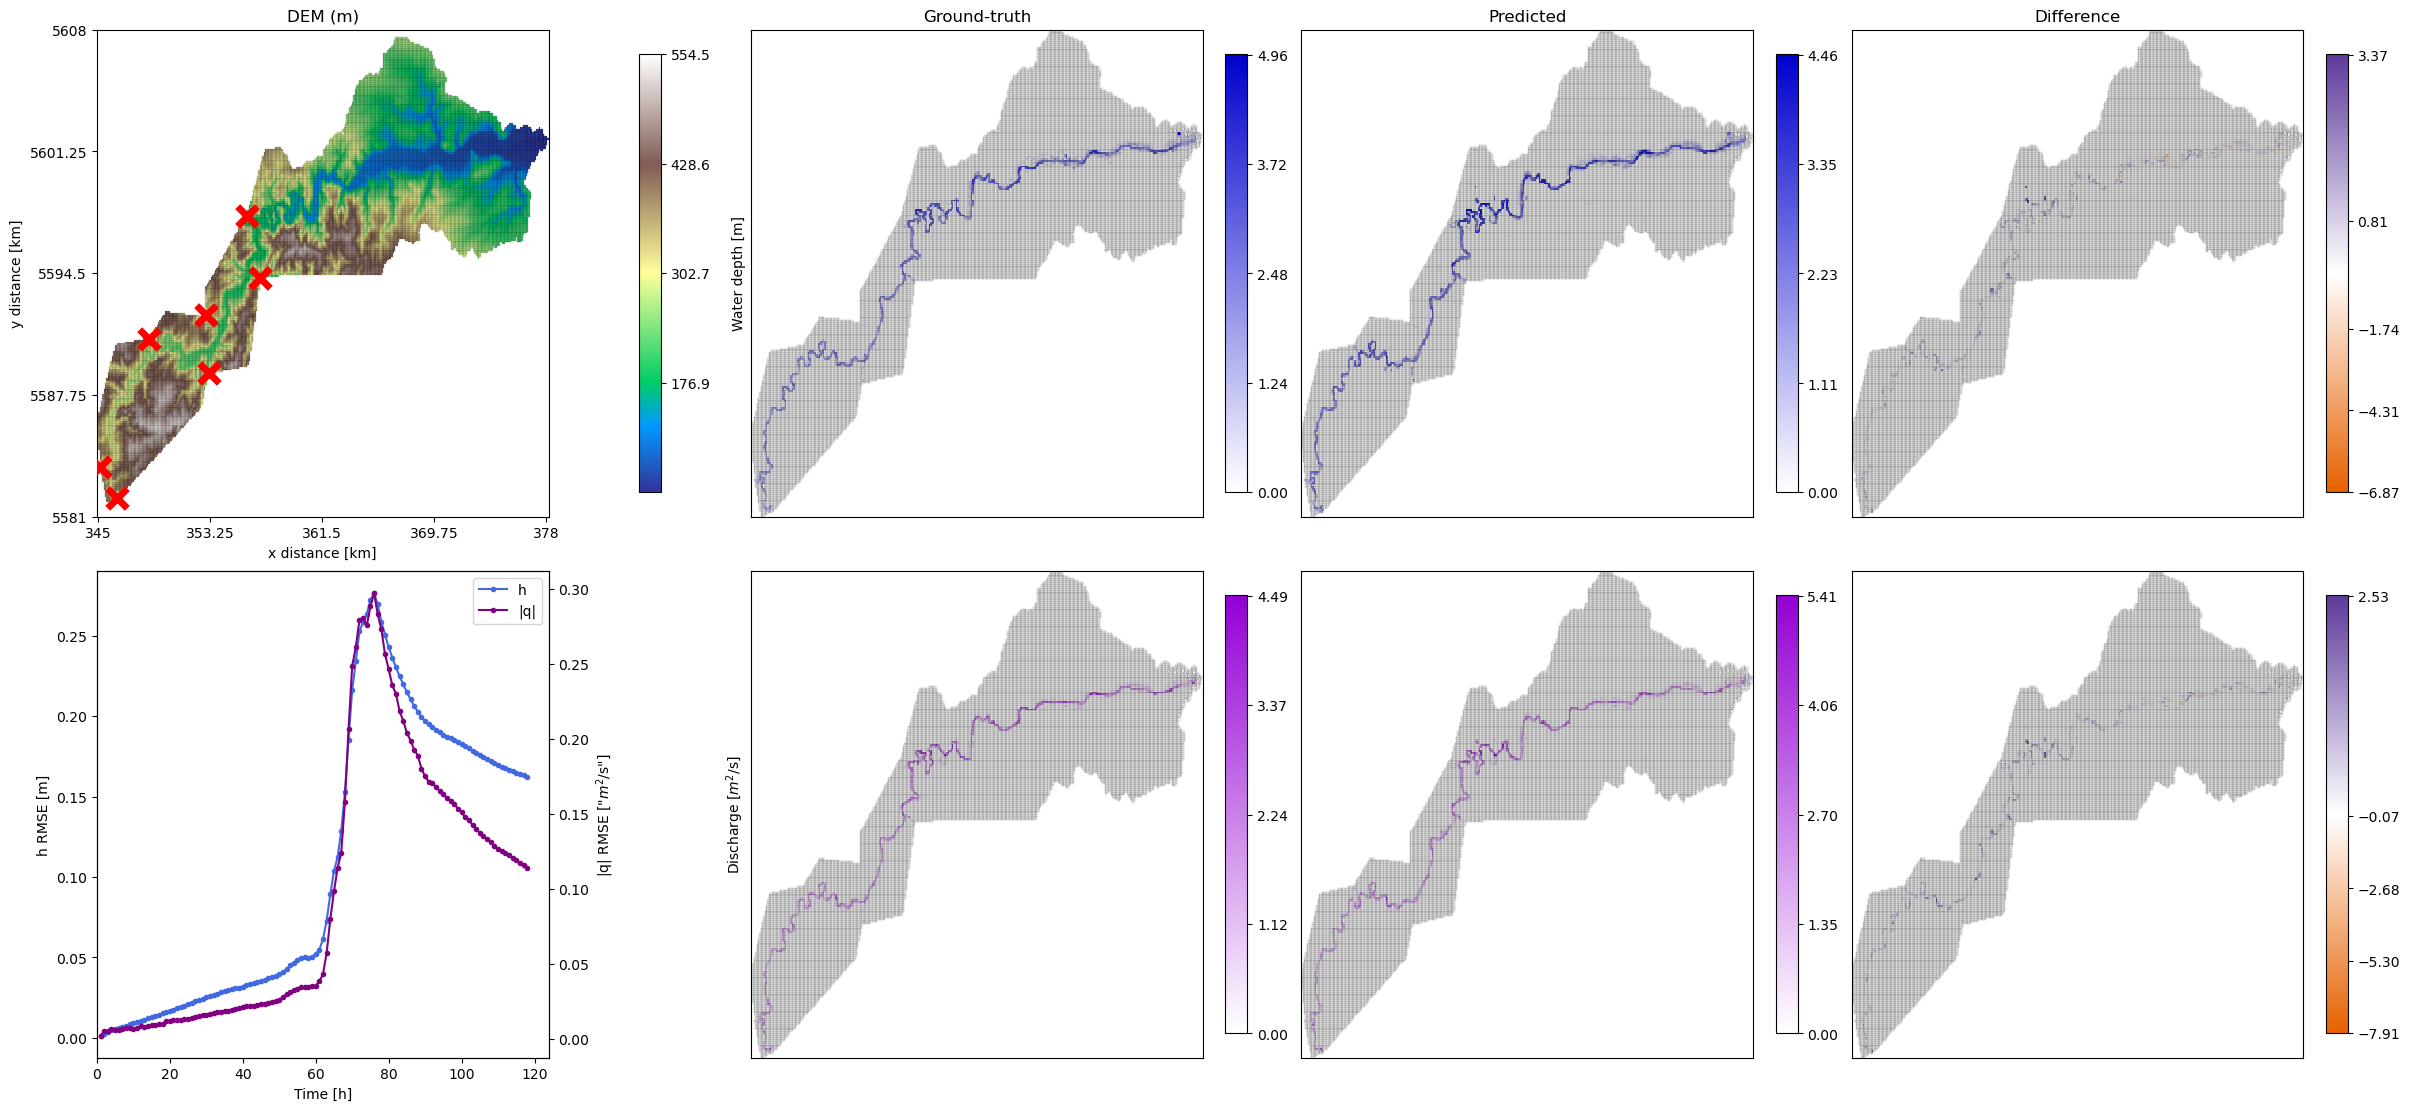

In [13]:
# Final-timestep flood map - all models side by side
for name, r in results.items():
    print(f'--- {name} ---')
    fig = r['plot_rollout'].explore_rollout(scale=0, time_step=-1)
    plt.show()

--- weircrest_best_valloss ---


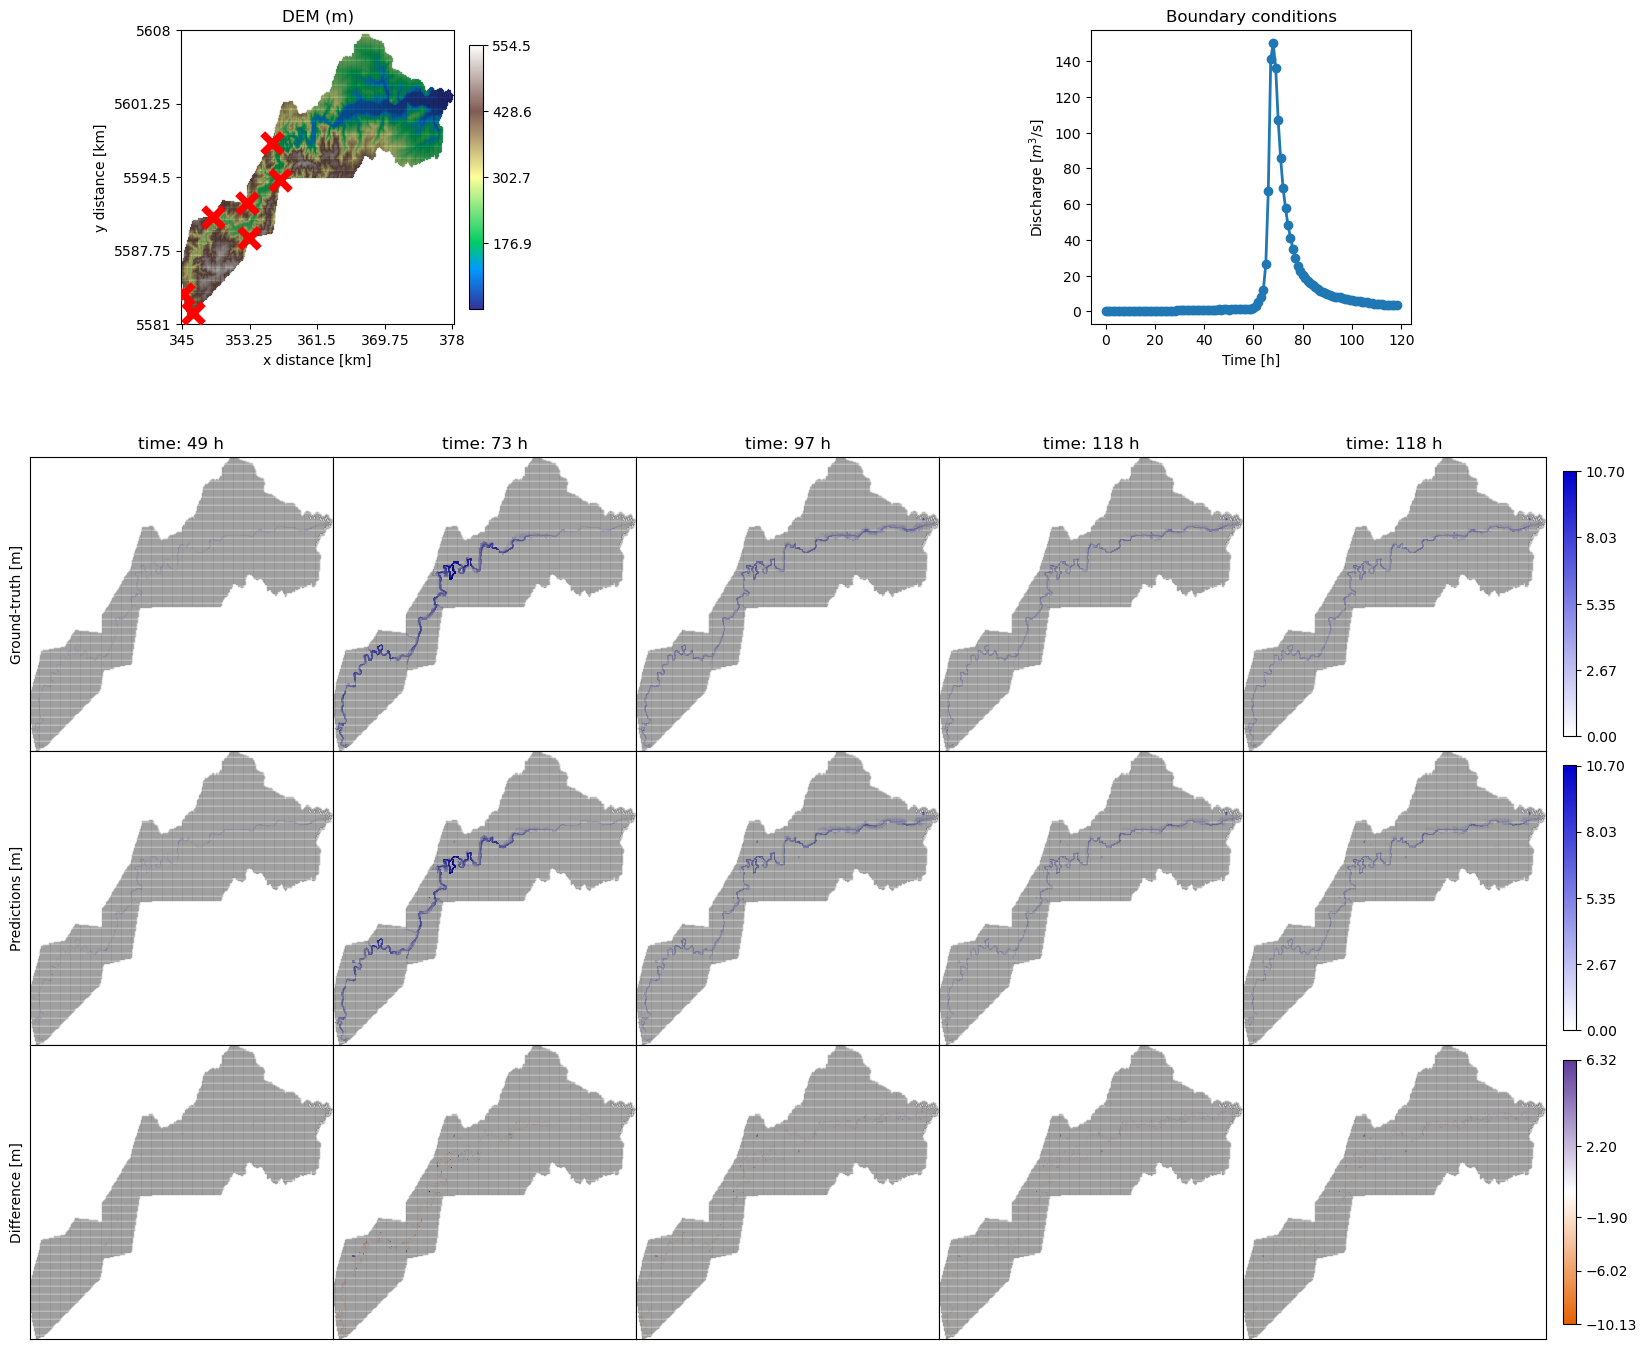

--- weircrest_bestCSI ---


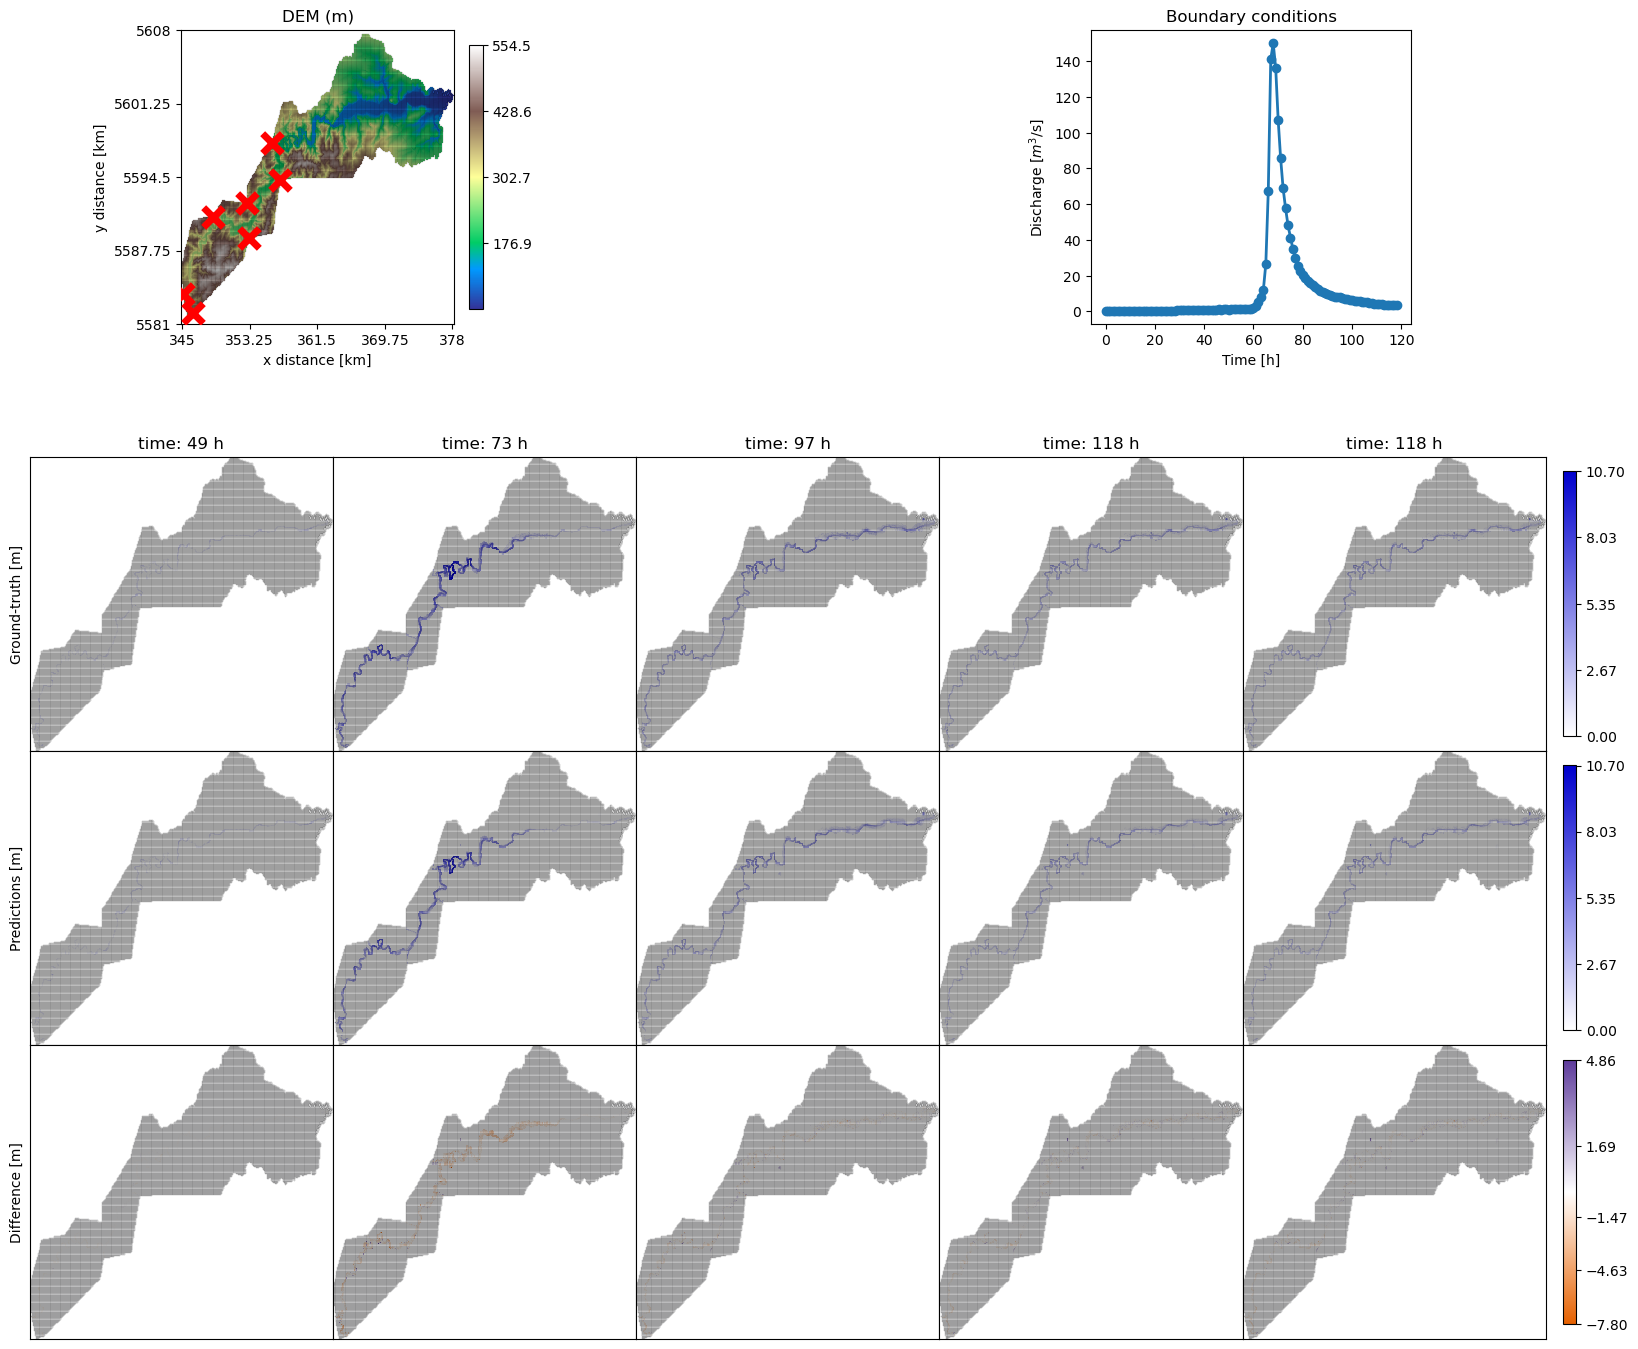

--- bcaugment_best_valloss ---


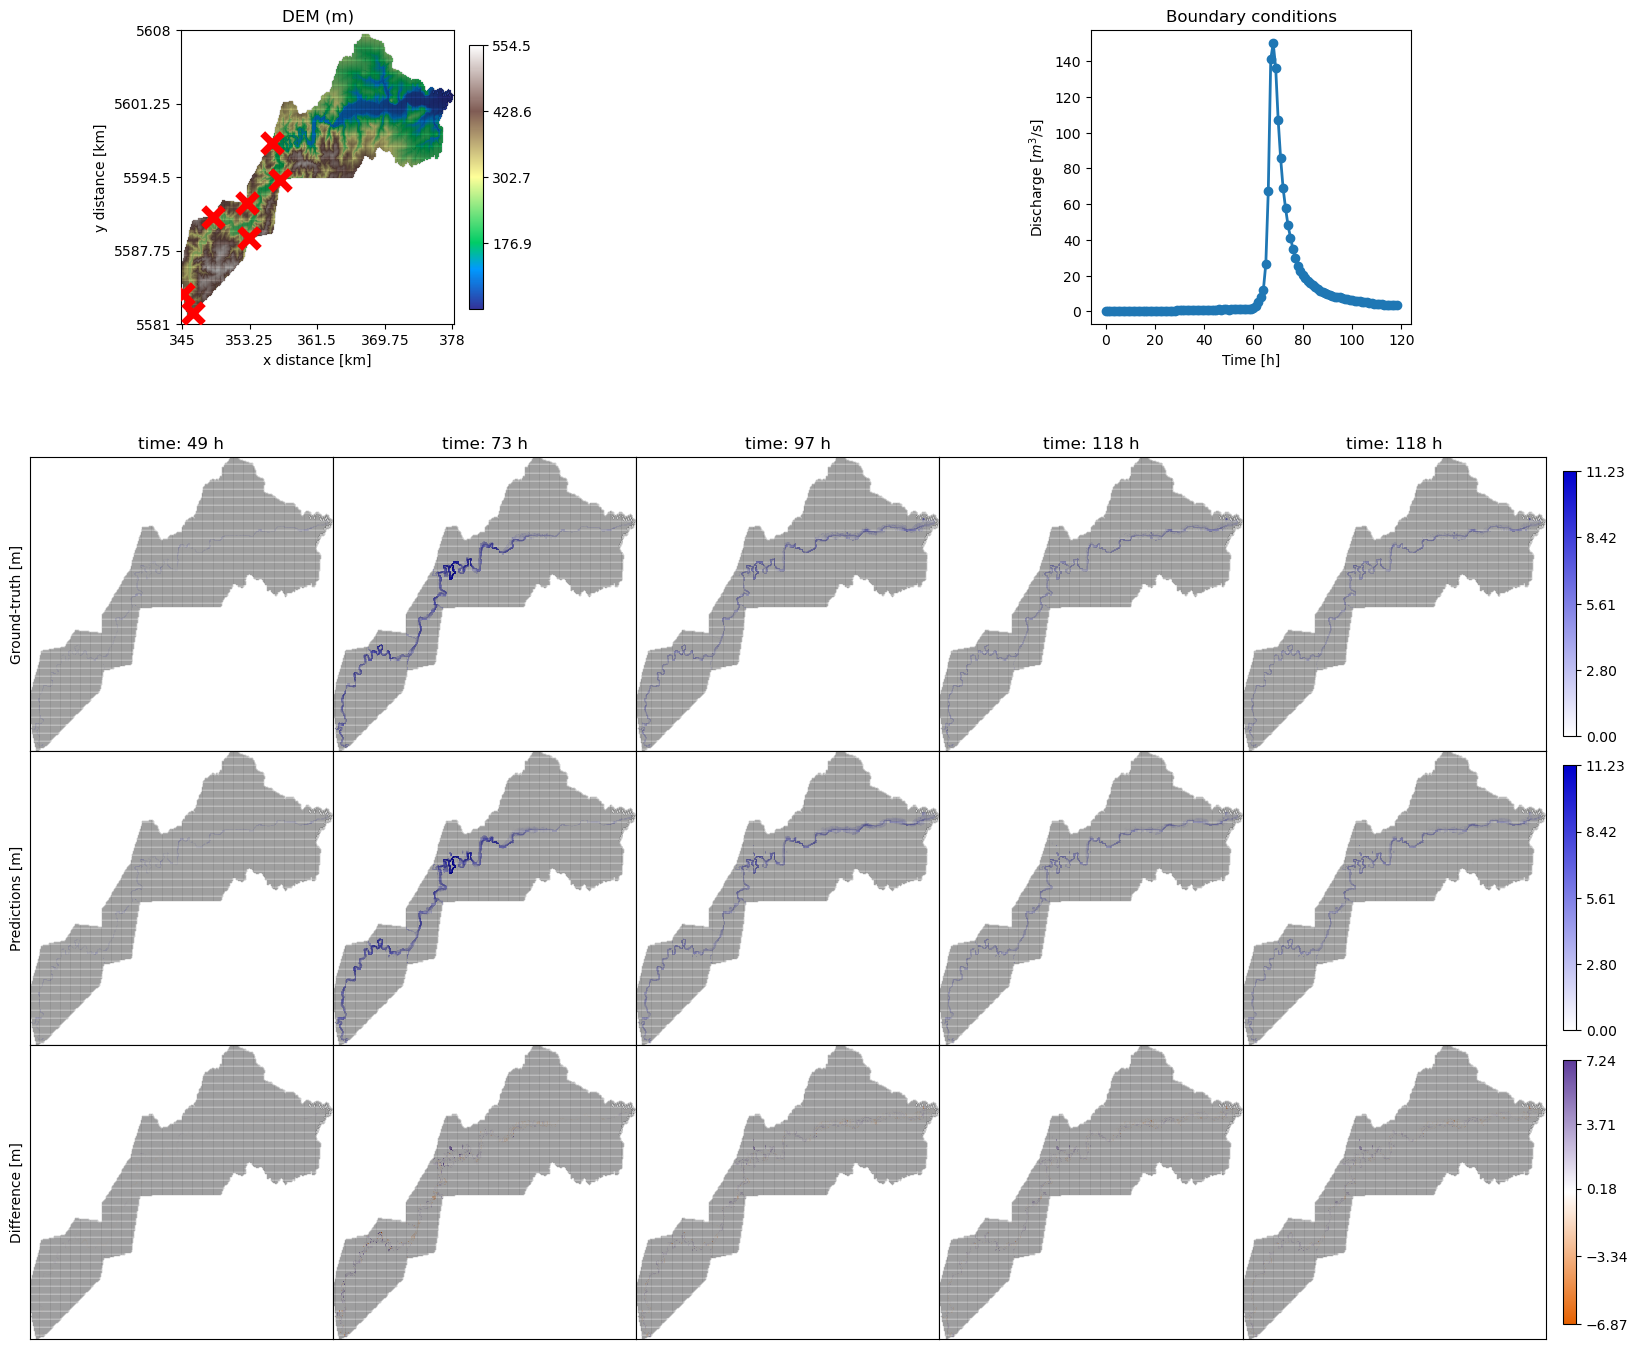

In [14]:
for name, r in results.items():
    print(f'--- {name} ---')
    n_steps = r['plot_rollout'].real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    r['plot_rollout'].compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()

## Forcing sensitivity - scale the BC hydrograph, measure the response
A physically meaningful surrogate must respond monotonically to the inflow. A flat response = event
memorization. Uses `weircrest_best_valloss` - check the epoch/per-scale-volume diagnostic above first,
swap to `weircrest_bestCSI` if best_valloss turns out to be the undertrained checkpoint.

BC x 0.00:  CSI@0.05=0.6952   WDsum@peak(t75)=     727   WDsum@end=     802   maxWD=2.66 m
BC x 0.50:  CSI@0.05=0.8541   WDsum@peak(t75)=    4438   WDsum@end=    2055   maxWD=8.41 m
BC x 0.75:  CSI@0.05=0.8660   WDsum@peak(t75)=    5822   WDsum@end=    2237   maxWD=9.19 m
BC x 1.00:  CSI@0.05=0.8716   WDsum@peak(t75)=    7396   WDsum@end=    2577   maxWD=10.60 m
BC x 1.25:  CSI@0.05=0.8714   WDsum@peak(t75)=    7850   WDsum@end=    2735   maxWD=11.13 m
BC x 1.50:  CSI@0.05=0.8632   WDsum@peak(t75)=    8471   WDsum@end=    2935   maxWD=12.31 m
BC x 2.00:  CSI@0.05=0.8467   WDsum@peak(t75)=    9660   WDsum@end=    3218   maxWD=15.09 m

ground truth (1x): WDsum@peak=7767   WDsum@end=2519   maxWD=10.71 m
persistence baseline: CSI@0.05=0.7506  CSI@0.30=0.7201


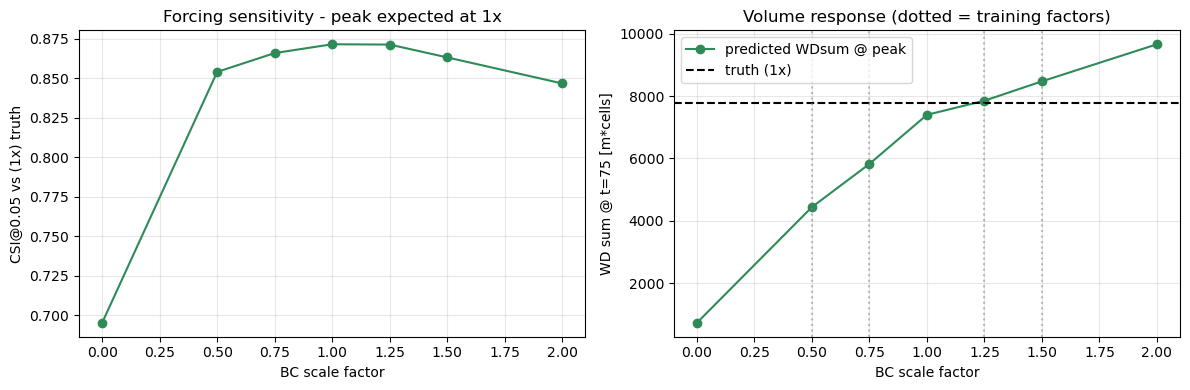

In [15]:
SENS_MODEL = 'weircrest_best_valloss'
r_sens = results[SENS_MODEL]
model_sens = r_sens['plot_rollout'].model
model_sens.eval()

_, _, _, ttdp_sens, _, _ = get_dataset_for_config(r_sens['config_path'])
temporal_test_dataset = to_temporal_dataset(r_sens['test_dataset'], rollout_steps=-1, **ttdp_sens)
td = temporal_test_dataset[0]
node_ptr = r_sens['test_dataset'][0].node_ptr
gt_s0 = separate_multiscale_node_features(td.y.detach(), node_ptr)[0]
ws_gt = gt_s0[:, 0, :].clamp(min=0).sum(0)
t_pk = int(ws_gt.argmax())

rows = []
for f in [0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    tdf = td.clone()
    tdf.BC = td.BC * f
    with torch.no_grad():
        pred = rollout_test_warmstart(model_sens, tdf, warmup_steps=0).detach()
    p_s0 = separate_multiscale_node_features(pred, node_ptr)[0]
    csi = get_CSI(p_s0, gt_s0, water_threshold=0.05).nanmean().item()
    ws = p_s0[:, 0, :].clamp(min=0).sum(0)
    rows.append((f, csi, float(ws[t_pk]), float(ws[-1]), float(p_s0[:, 0, :].max())))
    print(f'BC x {f:4.2f}:  CSI@0.05={csi:.4f}   WDsum@peak(t{t_pk})={ws[t_pk]:8.0f}   WDsum@end={ws[-1]:8.0f}   maxWD={p_s0[:,0,:].max():.2f} m')

print(f'\nground truth (1x): WDsum@peak={ws_gt[t_pk]:.0f}   WDsum@end={ws_gt[-1]:.0f}   maxWD={gt_s0[:,0,:].max():.2f} m')

persist = gt_s0[:, :, 0:1].repeat(1, 1, gt_s0.shape[-1])
print(f'persistence baseline: CSI@0.05={get_CSI(persist, gt_s0, water_threshold=0.05).nanmean().item():.4f}  '
      f'CSI@0.30={get_CSI(persist, gt_s0, water_threshold=0.30).nanmean().item():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fs = [r[0] for r in rows]
ax[0].plot(fs, [r[1] for r in rows], 'o-', color='seagreen')
ax[0].set_xlabel('BC scale factor'); ax[0].set_ylabel('CSI@0.05 vs (1x) truth')
ax[0].set_title('Forcing sensitivity - peak expected at 1x'); ax[0].grid(alpha=0.3)
ax[1].plot(fs, [r[2] for r in rows], 'o-', color='seagreen', label='predicted WDsum @ peak')
ax[1].axhline(float(ws_gt[t_pk]), ls='--', c='k', label='truth (1x)')
for f_train in [0.5, 0.75, 1.25, 1.5]:
    ax[1].axvline(f_train, color='grey', ls=':', alpha=0.5)
ax[1].set_xlabel('BC scale factor'); ax[1].set_ylabel(f'WD sum @ t={t_pk} [m*cells]')
ax[1].set_title('Volume response (dotted = training factors)')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## In-training-set sanity check: `alldrain`
`alldrain` (catchment emptying from the pre-flood baseline, all discharge = 0) is one of the 20
BC-augmentation events - part of `weircrest`'s 32-event merged training set too, not a synthetic probe.
If training worked, this should look close to perfect; if it doesn't, that's a real problem.

The validation dataset you are using is the training one. Careful!
alldrain (in-training-set, catchment emptying from baseline):
  RMSE_WD=0.1271  CSI@0.05=0.3472
  for context, weircrest_best_valloss on the held-out 1.0x event: RMSE_WD=0.0944  CSI@0.05=0.8716


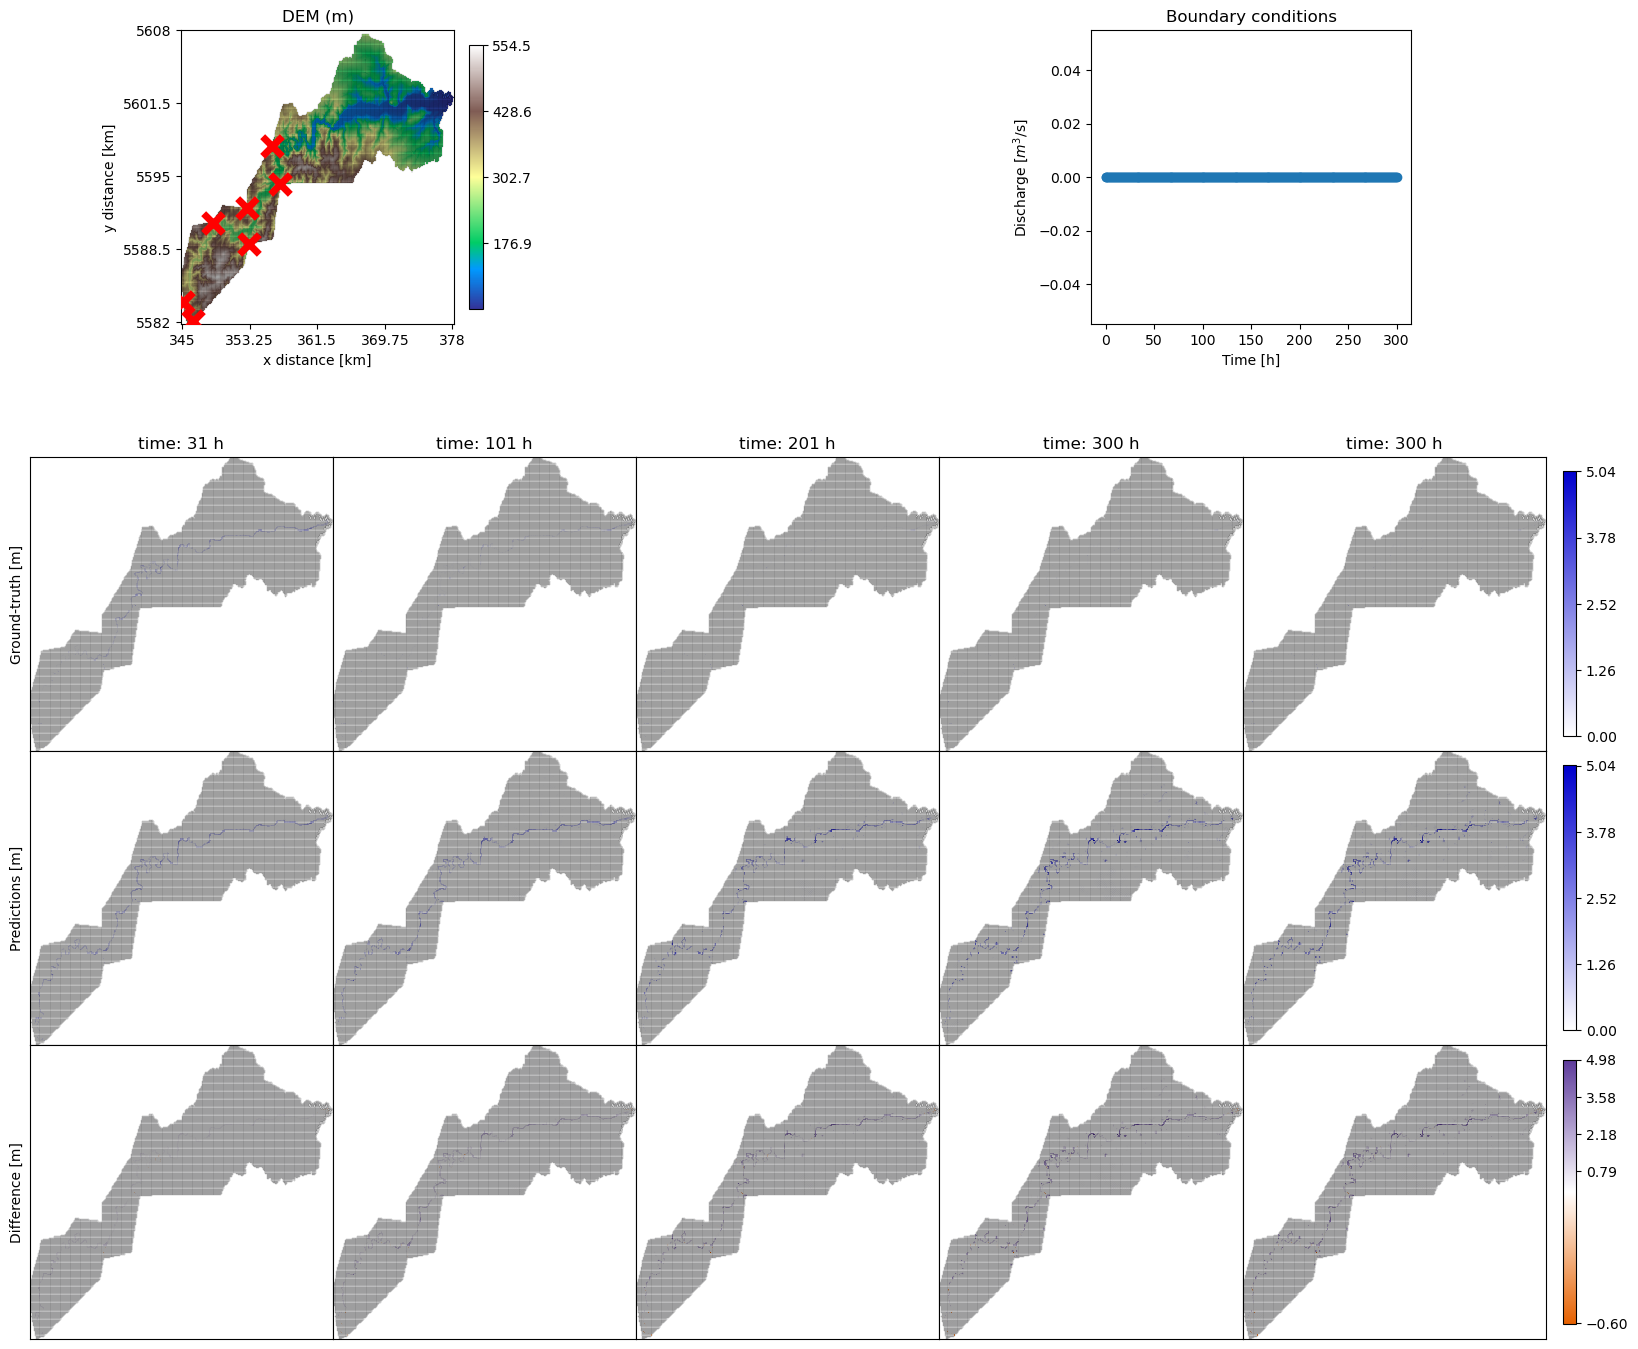

In [16]:
ALLDRAIN_NAME = 'ahr_river_v03_marg_alldrain_additionalsrc_velocity_100m_warmstart'

model_ad = results[SENS_MODEL]['plot_rollout'].model
model_ad.eval()

cfg_ad = read_config(results[SENS_MODEL]['config_path'])
cfg_ad['dataset_parameters']['test_dataset_name'] = ALLDRAIN_NAME
wandb.init(mode='disabled', project='mswe-gnn', config=cfg_ad, reinit=True)
fix_dict_in_config(wandb)
config_ad = wandb.config
_, _, test_dataset_ad, scalers_ad = create_model_dataset(
    scalers=config_ad.scalers, device=device,
    **config_ad.dataset_parameters,
    **config_ad.selected_node_features,
    **config_ad.selected_edge_features)
ttdp_ad = get_temporal_test_dataset_parameters(config_ad, config_ad.temporal_dataset_parameters)

pr_alldrain = PlotRollout(model_ad, test_dataset_ad[0], scalers=scalers_ad, warmup_steps=0, **ttdp_ad)

rl = pr_alldrain._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_alldrain = rl[0].item() if rl.ndim > 0 else rl.item()
csi005_alldrain = pr_alldrain._get_CSI(water_threshold=0.05).nanmean().item()
print(f'alldrain (in-training-set, catchment emptying from baseline):')
print(f'  RMSE_WD={rmse_alldrain:.4f}  CSI@0.05={csi005_alldrain:.4f}')
print(f'  for context, {SENS_MODEL} on the held-out 1.0x event: '
      f"RMSE_WD={results[SENS_MODEL]['rmse_wd']:.4f}  CSI@0.05={results[SENS_MODEL]['csi_005']:.4f}")

n_steps_alldrain = pr_alldrain.real_rollout.shape[-1]
plot_times = [n_steps_alldrain // 10, n_steps_alldrain // 3, 2 * n_steps_alldrain // 3, n_steps_alldrain - 1]
pr_alldrain.compare_h_rollout(plot_times=plot_times, scale=0)
plt.show()

### Short-horizon check: is this compounding drift, or a wrong learned decay rate?

`alldrain` was only ever seen in training as 5-step windows (`rollout_steps` curriculum caps out at 5),
and it's the *only* one of the 20 BC-augmentation events that drains all the way to near-zero. If the
full-rollout result above looks bad, two different explanations produce the same symptom but call for
opposite fixes:
1. **Rollout-length compounding** - short-horizon dynamics are correct, drift only appears once the
   autoregressive chain runs far past what curriculum learning ever trained on.
2. **Insufficient exposure to this regime** - the model never learned the near-zero-water decay
   behavior properly at all, regardless of horizon length (only one real training example of it).

Comparing a short window (well beyond `rollout_steps=5`, far short of the full trajectory) against the
full rollout separates these: bad-even-short points at (2), fine-short-but-bad-long points at (1).

alldrain, first 20 steps only:
  RMSE_WD=0.0211  CSI@0.05=0.9232
  for context, same model on the FULL ~300-step alldrain rollout: RMSE_WD=0.1271  CSI@0.05=0.3472


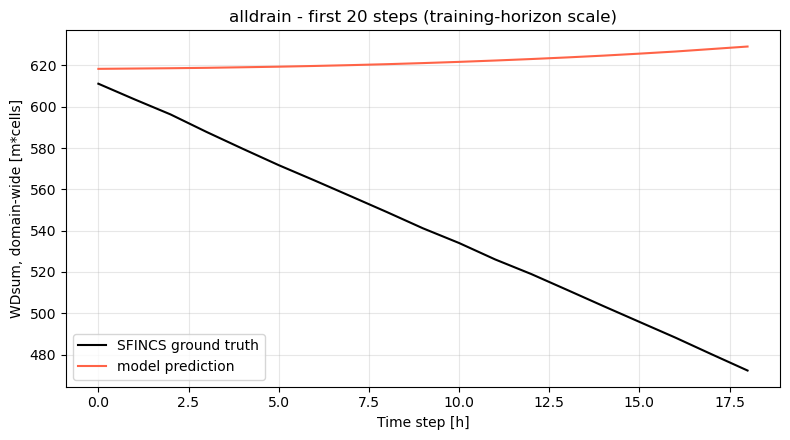

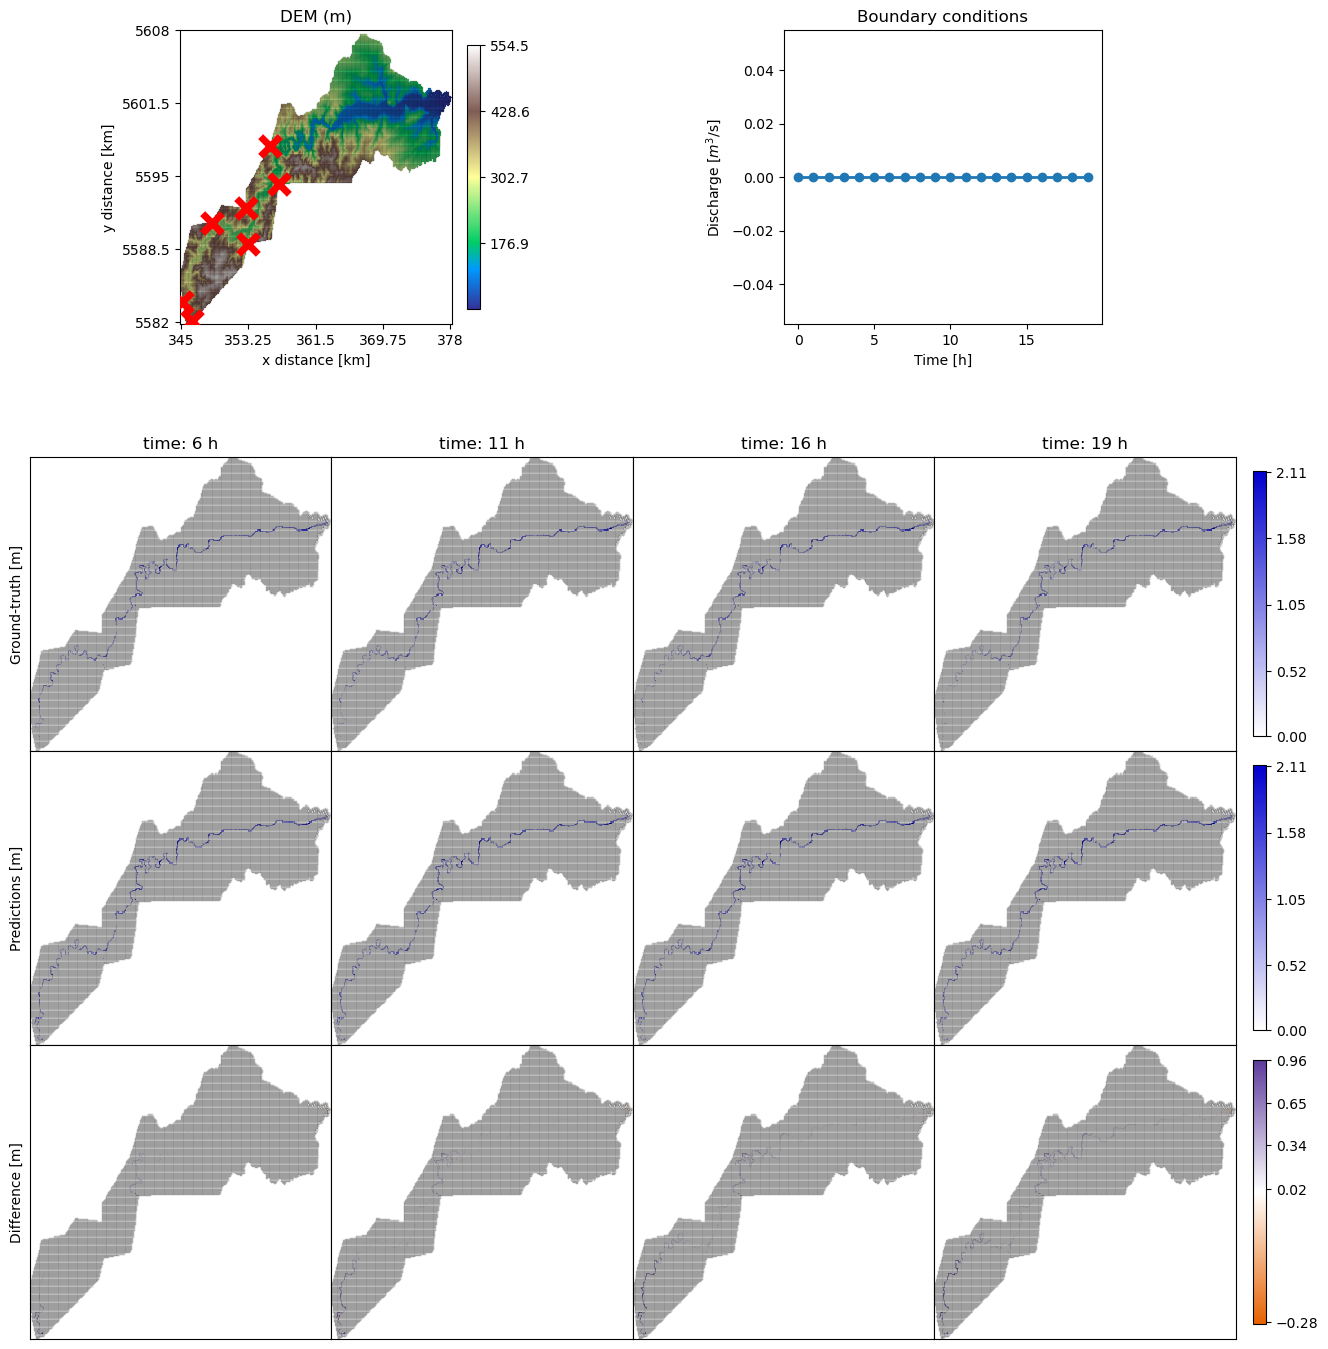

In [17]:
SHORT_STEPS = 20  # well beyond the training rollout_steps=5, far short of the full ~300-step trajectory

short_data = copy.deepcopy(test_dataset_ad[0])
short_data.WD = short_data.WD[:, :SHORT_STEPS]
short_data.V  = short_data.V[:, :SHORT_STEPS]
short_data.BC = short_data.BC[:, :SHORT_STEPS]  # BC is already 2D [n_bc, T] at this stage, not [n_bc, T, 2]

pr_alldrain_short = PlotRollout(model_ad, short_data, scalers=scalers_ad, warmup_steps=0, **ttdp_ad)

rl_short = pr_alldrain_short._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_short = rl_short[0].item() if rl_short.ndim > 0 else rl_short.item()
csi005_short = pr_alldrain_short._get_CSI(water_threshold=0.05).nanmean().item()
print(f'alldrain, first {SHORT_STEPS} steps only:')
print(f'  RMSE_WD={rmse_short:.4f}  CSI@0.05={csi005_short:.4f}')
print(f'  for context, same model on the FULL ~{n_steps_alldrain}-step alldrain rollout: '
      f'RMSE_WD={rmse_alldrain:.4f}  CSI@0.05={csi005_alldrain:.4f}')

real_ws_short = pr_alldrain_short._real_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()
pred_ws_short = pr_alldrain_short._predicted_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(real_ws_short, label='SFINCS ground truth', color='k')
ax.plot(pred_ws_short, label='model prediction', color='tomato')
ax.set_xlabel('Time step [h]')
ax.set_ylabel('WDsum, domain-wide [m*cells]')
ax.set_title(f'alldrain - first {SHORT_STEPS} steps (training-horizon scale)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# compare_h_rollout appends the final step (-1) automatically, and the rollout here has fewer
# columns than SHORT_STEPS (the first previous_t steps are consumed as model input, not output),
# so don't pass SHORT_STEPS - 1 explicitly - it can be one step past the end.
pr_alldrain_short.compare_h_rollout(plot_times=[5, 10, 15], scale=0)
plt.show()

## Inference at 2x and 3x BC
Extrapolation ladder beyond the training range. Uses `template_100m.pkl`-based q200/q300 test pkls
(no structures) - `edge_weir_crest` falls back to all-zero for these via `get_edge_features()`'s
getattr fallback, which is correct here (genuinely no structures in this scenario).

In [18]:
EXTRAP = {'q200': 2.0, 'q300': 3.0}
extrap_pr = {}
extrap_rows = []
for tag, f in EXTRAP.items():
    name = f'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_{tag}'
    if not os.path.exists(f'database/datasets/test/{name}.pkl'):
        print(f'[skip] {tag}: database/datasets/test/{name}.pkl not found')
        continue

    cfg_f = read_config(results[SENS_MODEL]['config_path'])
    cfg_f['dataset_parameters']['test_dataset_name'] = name
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg_f, reinit=True)
    fix_dict_in_config(wandb)
    config_f = wandb.config
    _, _, test_f, scalers_f = create_model_dataset(
        scalers=config_f.scalers, device=device,
        **config_f.dataset_parameters,
        **config_f.selected_node_features,
        **config_f.selected_edge_features)

    _, _, _, ttdp_f, _, _ = get_dataset_for_config(results[SENS_MODEL]['config_path'])
    pr = PlotRollout(model_ad, test_f[0], scalers=scalers_f, warmup_steps=0, **ttdp_f)
    extrap_pr[tag] = pr

    rl = pr._get_rollout_loss(type_loss='RMSE').mean(0)
    rmse = rl[0].item() if rl.ndim > 0 else rl.item()
    csi005 = pr._get_CSI(water_threshold=0.05).nanmean().item()
    csi03  = pr._get_CSI(water_threshold=0.30).nanmean().item()
    extrap_rows.append((f, rmse, csi005, csi03))
    print(f'BC x {f}:  RMSE_WD={rmse:.4f}  CSI@0.05={csi005:.4f}  CSI@0.30={csi03:.4f}')

if extrap_rows:
    print(f"\ncontext - {SENS_MODEL} on 1.0x: "
          f"RMSE_WD={results[SENS_MODEL]['rmse_wd']:.4f}  "
          f"CSI@0.05={results[SENS_MODEL]['csi_005']:.4f}  "
          f"CSI@0.30={results[SENS_MODEL]['csi_03']:.4f}")
    print('generalization ladder: 1.0x = interpolation | 2x = moderate extrapolation | 3x = aggressive extrapolation')

The validation dataset you are using is the training one. Careful!
BC x 2.0:  RMSE_WD=0.1729  CSI@0.05=0.8558  CSI@0.30=0.8907
The validation dataset you are using is the training one. Careful!
BC x 3.0:  RMSE_WD=0.3246  CSI@0.05=0.8286  CSI@0.30=0.8603

context - weircrest_best_valloss on 1.0x: RMSE_WD=0.0944  CSI@0.05=0.8716  CSI@0.30=0.9024
generalization ladder: 1.0x = interpolation | 2x = moderate extrapolation | 3x = aggressive extrapolation


--- weircrest_best_valloss on q200 (vs its own SFINCS ground truth) ---


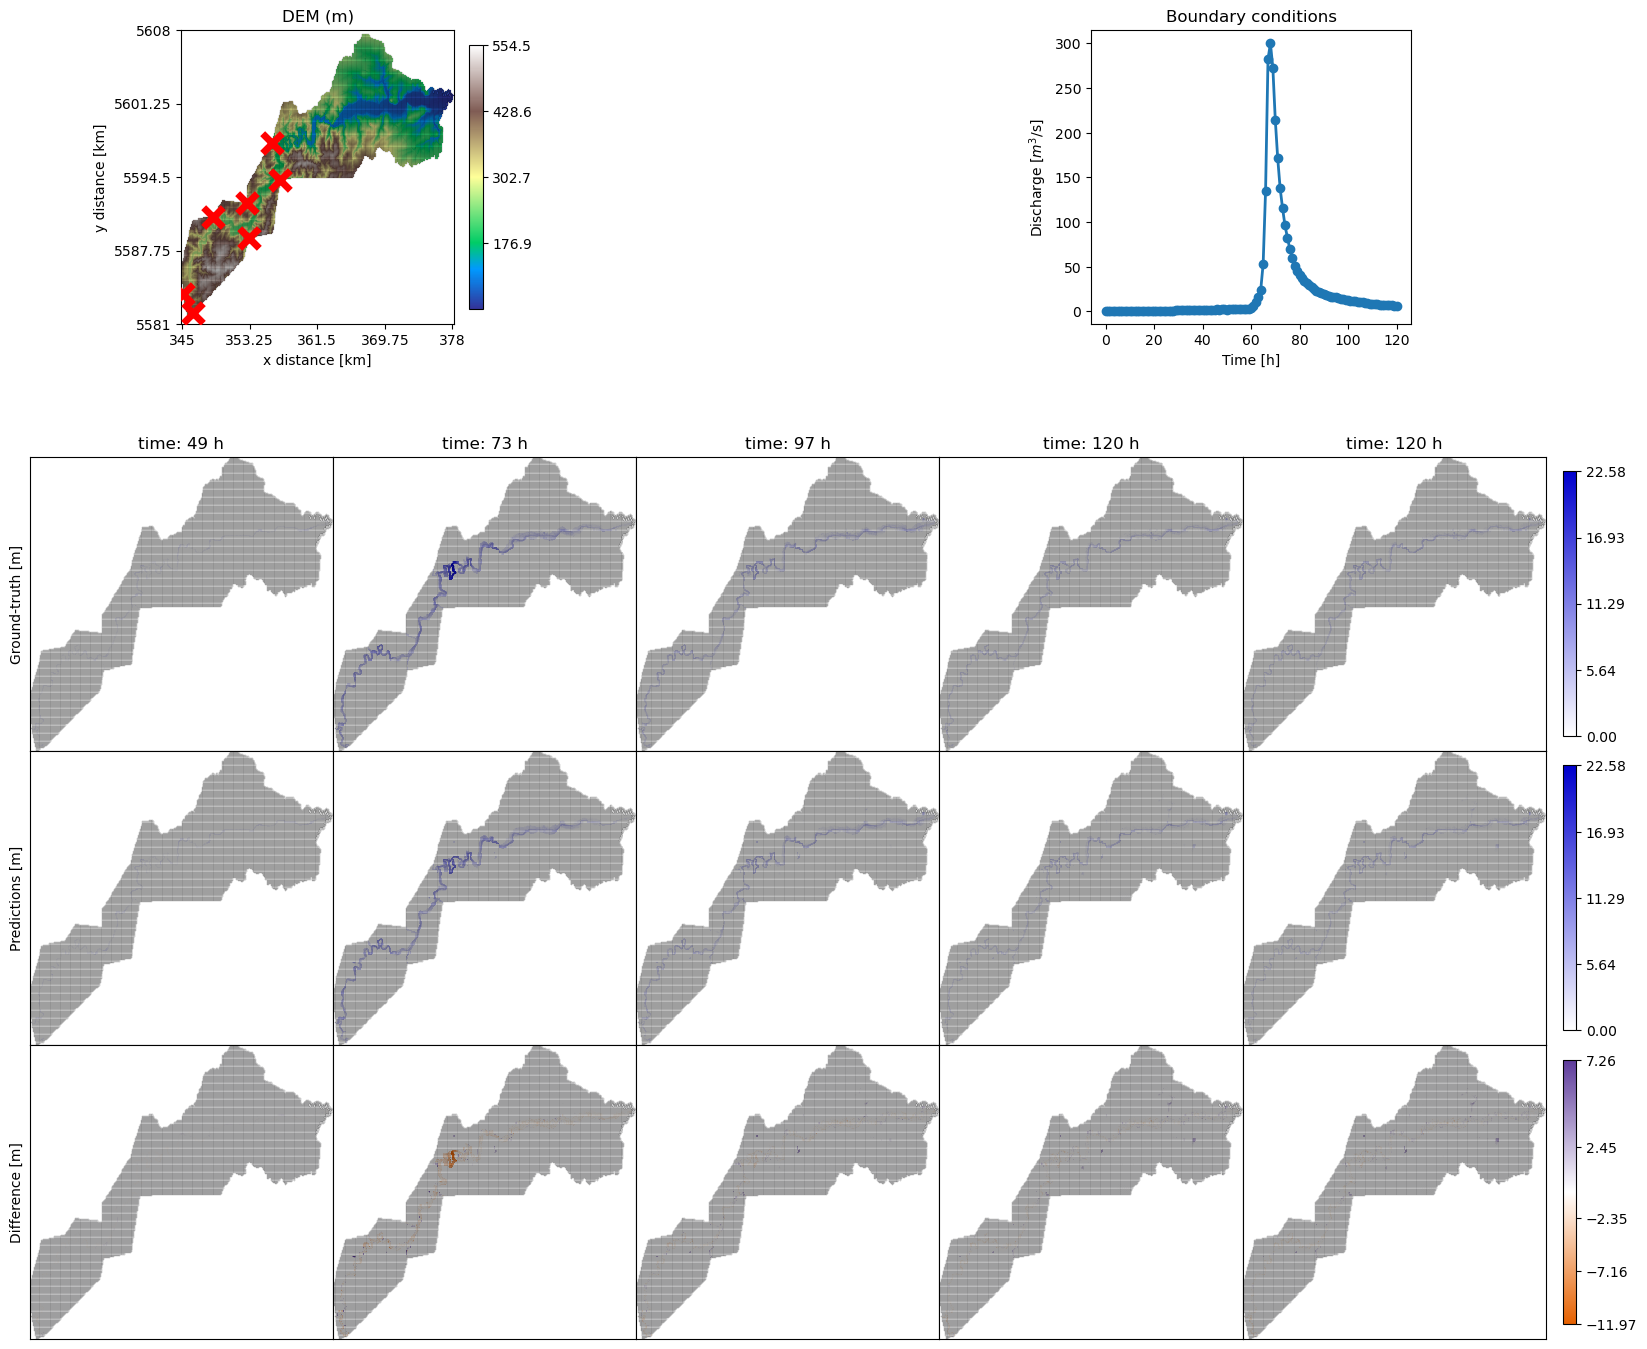

--- weircrest_best_valloss on q300 (vs its own SFINCS ground truth) ---


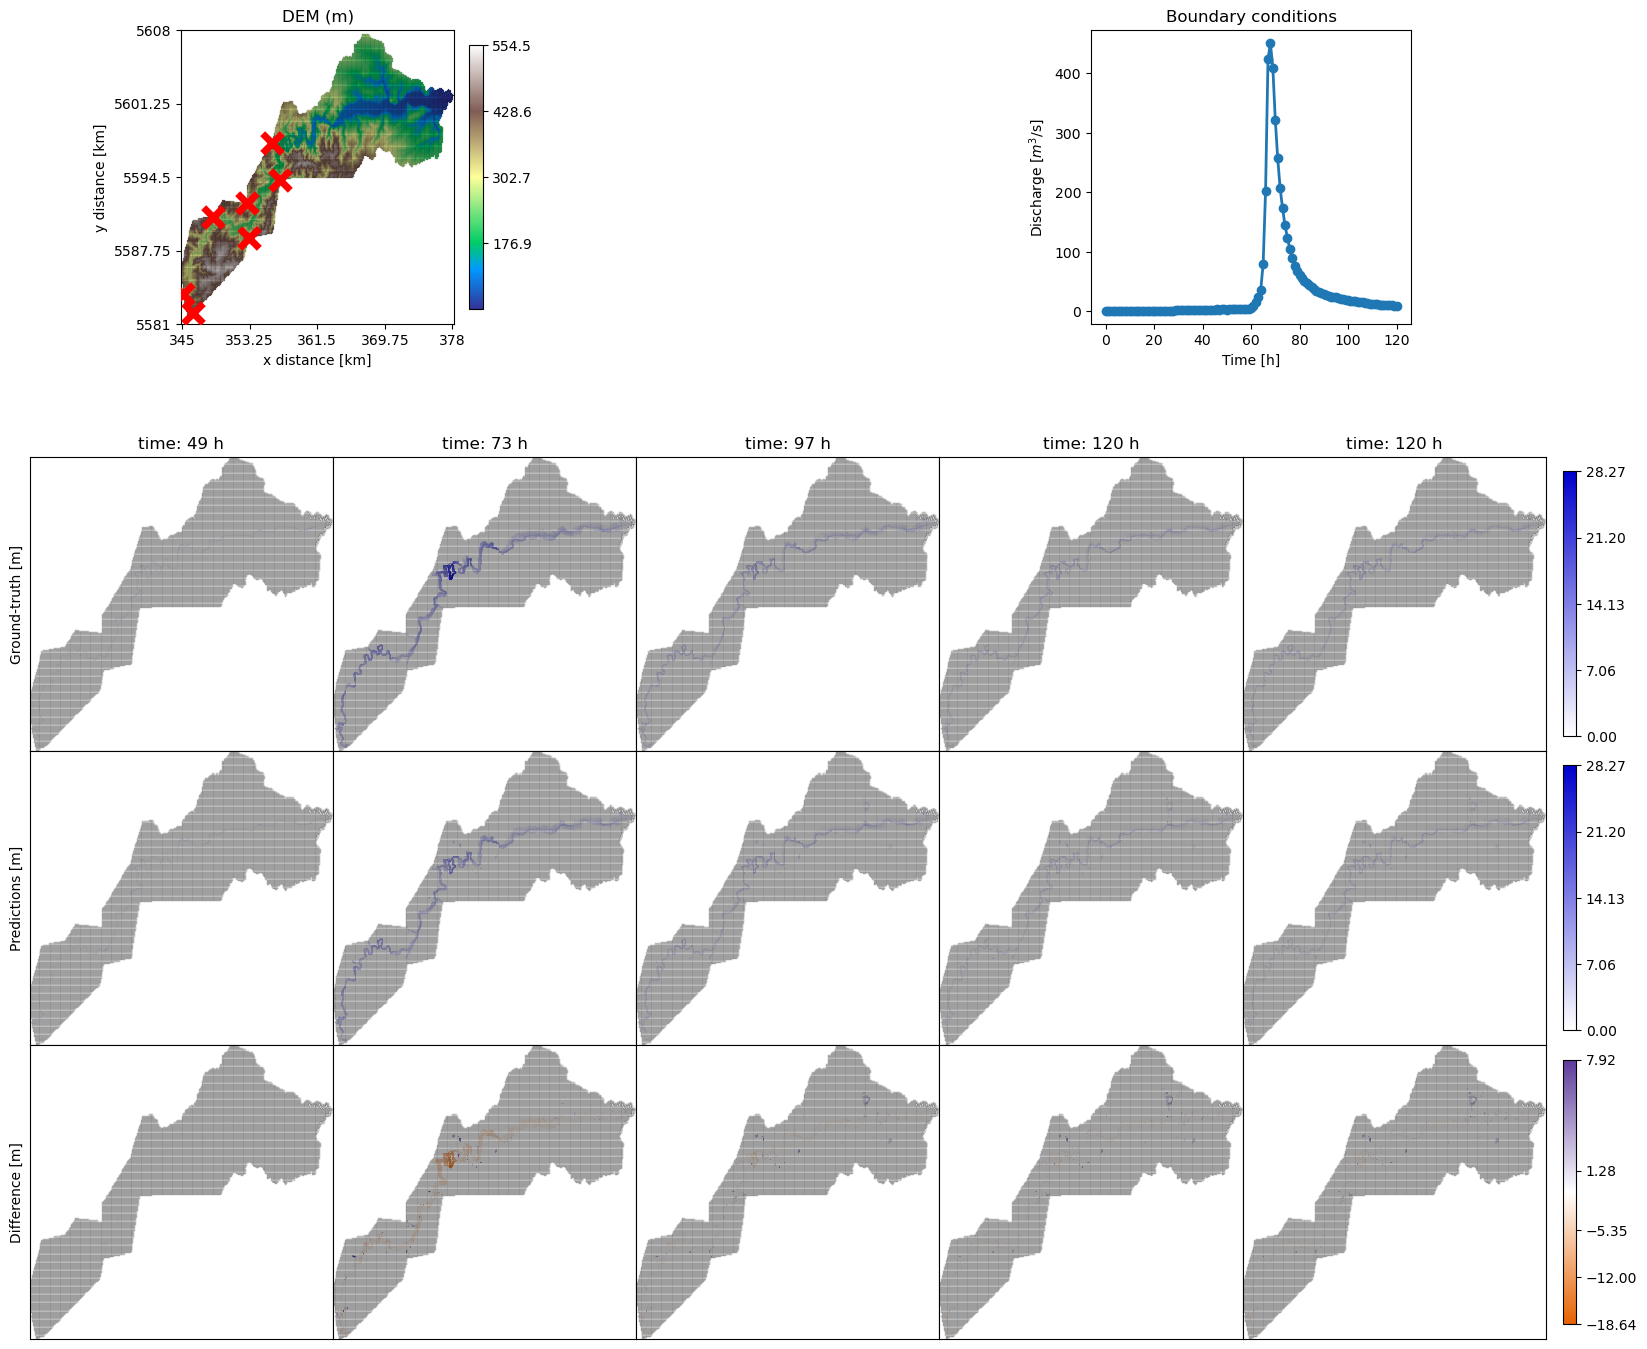

In [19]:
for tag, pr in extrap_pr.items():
    print(f'--- {SENS_MODEL} on {tag} (vs its own SFINCS ground truth) ---')
    n_steps = pr.real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    pr.compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()